# Assignment 2

## Loading cell-data:

In [1]:
#relaoding the old variables of the kernel
import dill 
dill.load_session('PickleAssignment2.db')

In [1]:
#load data
import numpy as np
data = np.load("cell-data.npz")
images = data["images"]
counts = data["counts"]
folds = data["folds"]
X0 = images[folds == 0]
Y0 = counts[folds == 0]
X1 = images[folds == 1] #Using the 2nd Fold for validation (Fold = 1)
Y1 = counts[folds == 1]
X2 = images[folds == 2] #Using the 3rd Fold for validation (Fold = 2)
Y2 = counts[folds == 2]

## Question 1 

### i)

In [2]:
for i in range (0,3):
    print('In the %i. Fold we have %i Examples' % (i+1, len(images[folds == i])))
# =============================================================================
# outputs the length of each example, which is equal to the number of examples in each fold,
# since each entry represents one example.
# =============================================================================

In the 1. Fold we have 827 Examples
In the 2. Fold we have 749 Examples
In the 3. Fold we have 775 Examples


### ii)

| Image No. 809	|#T1-cells = 99	|#T2-cells = 0	|#T3-cells = 4	|#T4-cells = 0	|#T5-cells = 0	|#T6-cells = 1	|
| Image No. 117	|#T1-cells = 0	|#T2-cells = 69	|#T3-cells = 3	|#T4-cells = 0	|#T5-cells = 0	|#T6-cells = 1	|
| Image No. 769	|#T1-cells = 0	|#T2-cells = 8	|#T3-cells = 24	|#T4-cells = 0	|#T5-cells = 0	|#T6-cells = 1	|
| Image No. 776	|#T1-cells = 11	|#T2-cells = 1	|#T3-cells = 0	|#T4-cells = 6	|#T5-cells = 0	|#T6-cells = 1	|
| Image No. 86	|#T1-cells = 0	|#T2-cells = 1	|#T3-cells = 0	|#T4-cells = 0	|#T5-cells = 65	|#T6-cells = 1	|
| Image No. 0	|#T1-cells = 4	|#T2-cells = 2	|#T3-cells = 2	|#T4-cells = 0	|#T5-cells = 0	|#T6-cells = 1	|


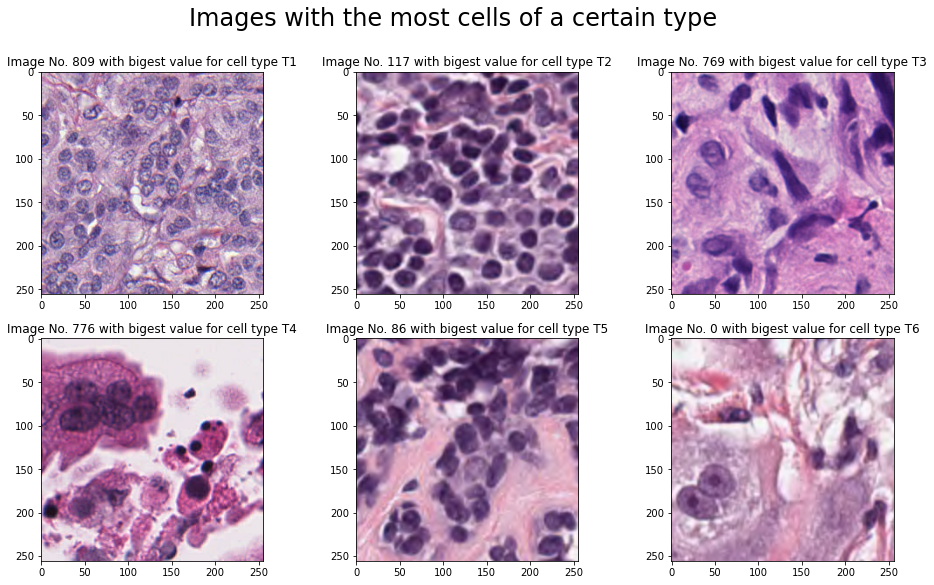

In [3]:
import matplotlib.pyplot as plt
fig=plt.figure(figsize=(16,9))
plt.suptitle('Images with the most cells of a certain type', fontsize=24)
for i in range (0,6):
    ax = fig.add_subplot(2, 3, i+1)
    a = np.argmax(Y0[:,i])
    ax.imshow(images[a])
    ax.set_title('Image No. %i with bigest value for cell type T%i' % (a,i+1))    
    print('| Image No. %i\t|#T1-cells = %i\t|#T2-cells = %i\t|#T3-cells = %i\t|#T4-cells = %i\t|#T5-cells = %i\t|#T6-cells = %i\t|' % (a,Y0[a,0],Y0[a,1],Y0[a,2],Y0[a,3],Y0[a,4],Y0[a,5]))
# =============================================================================
# outputs the Image with the bigest cell counter of each Cell Type T1 - T5
# =============================================================================

If you know the number of cells of a certain type in an image then the cells are mostly easy and intuitive to recognise. T1, T3 and T5 (shown in Image 809, 117 and 86) are not that hard to distinguish. T1 Cells are dark purple but appear more transparent than the other two types. T2 and T5 are presented by big dark purple stains, these differ in size. T2 cells seem smaller to me than T3 cells. On Image 769 we have 3 times more T3-Cells than T2-Cells. Nevertheless, they are hard to distinguish. I suspect that these pink spots represent T3 cells. Also because they occur sporadically on image 809 and image 117. To recognize the T4-Cells is very hard, also because we do not have them on other images. Since T6 cells appear in pretty much every picture and do not have a striking or unique shape, they are also difficult to identify.

### iii)

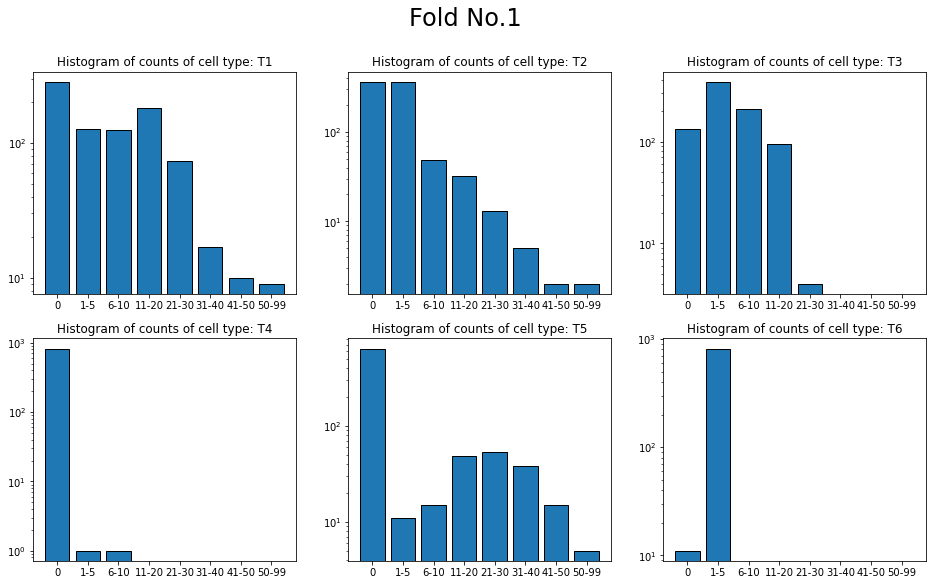

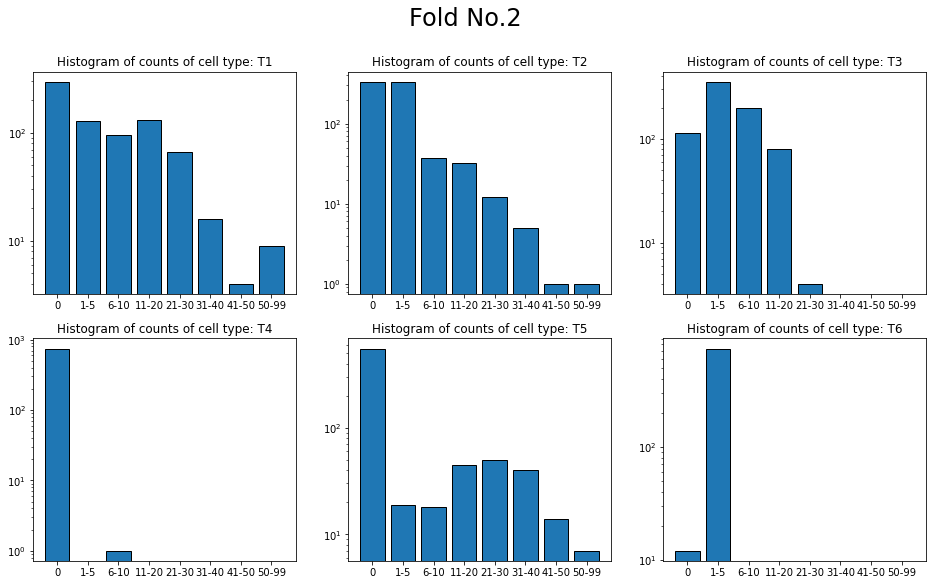

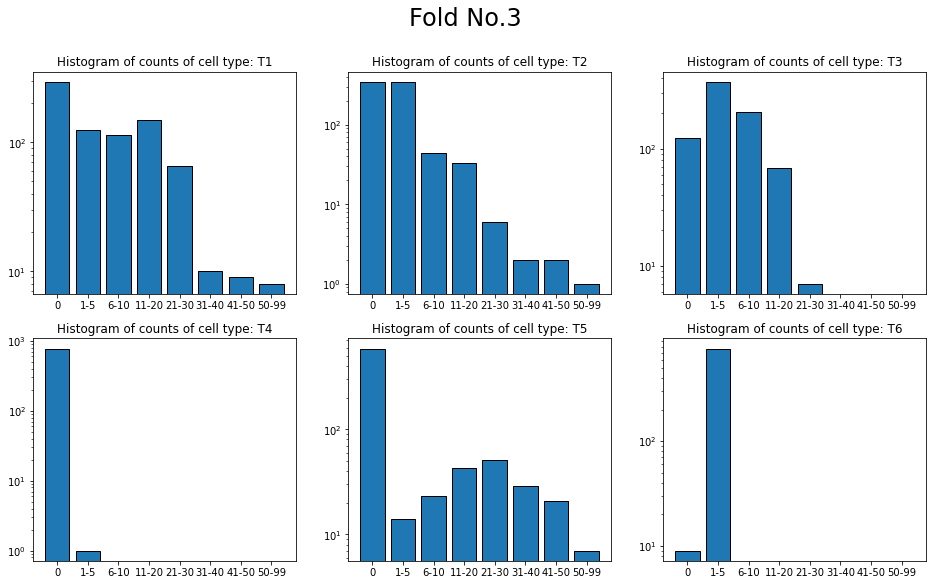

In [4]:
bins = [0, 1, 6, 11, 21, 31, 41, 51, 99] #the bins
for i in range (0,3): 
    fig=plt.figure(figsize=(16,9))
    plt.suptitle('Fold No.%i' %(i+1), fontsize=24)
    for j in range(0,6): #For each fold it outputs six histograms of counts of cell, refering each to a certain cell type
        ax = fig.add_subplot(2, 3, j+1)
        x = counts[folds == i,][:,j]
        h,e = np.histogram(x, bins=bins)
        ax.bar(range(len(bins)-1), h, width=0.8, edgecolor='k')
        labels = ['0', '1-5', '6-10','11-20', '21-30', '31-40', '41-50', '50-99']
        plt.xticks(range(len(bins)-1), labels)
        plt.yscale('log') # using log-scale beacuse it visualzizes the situations better. 'comment it with #' to see linear-scale
        ax.set_title('Histogram of counts of cell type: T%i' % (j+1))

### iv)

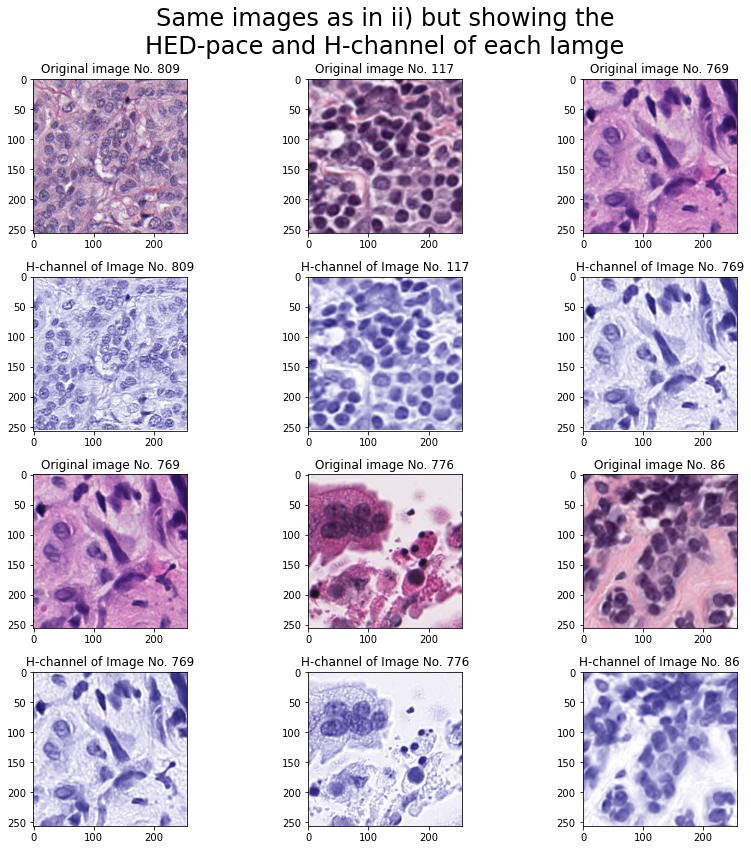

In [5]:
from skimage.color import rgb2hed, hed2rgb

fig=plt.figure(figsize=(12,12))
plt.suptitle('Same images as in ii) but showing the\nHED-pace and H-channel of each Iamge', fontsize='24')

for j in range(0,2):
    for i in range (j*2,3+j*2):
        m = np.argmax(Y0[:,i]) #comapre ii)
        ax = fig.add_subplot(4, 3, i+1+j*4)
        I_hed = rgb2hed(images[m]); im = ax.imshow(images[m]); #fig.colorbar(im)  #converting from RGB space to HED-space
        ax.set_title('Original image No. %i' % (m))
        ax = fig.add_subplot(4, 3, i+4+j*4)
        null = np.zeros_like(I_hed[:, :, 0])
        toll = np.stack((I_hed[:, :, 0], null, null), axis=-1)
        #toll = np.stack((null, I_hed[:, :, 1], null), axis=-1) #uncomment for E-Channel
        #toll = np.stack((null, null, I_hed[:, :, 2]), axis=-1)   #uncomment for D-Channel      
        I_h = I_hed[:,:,0]; im = ax.imshow(hed2rgb(toll)); #fig.colorbar(im)   #extracting H-Channel of HED-Space
        ax.set_title('H-channel of Image No. %i' % (m))
fig.tight_layout() #fixing layout

### v)

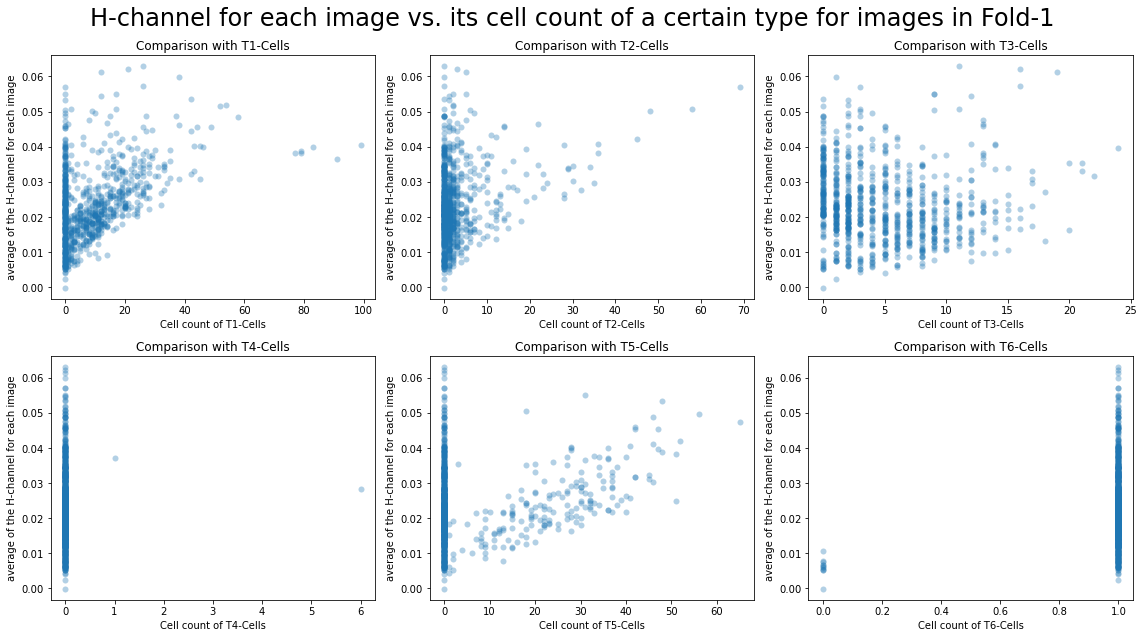

In [6]:
I_hed = rgb2hed(X0) #converting every image of Fold=0 (referng to Fold-1)in to the HED-Space 
I_h = I_hed[:,:,:,0] #extracting the H-Channel. In this case the last entry determines a certain Channel 
immeans = np.mean(I_h,axis= (1,2)) #calculating the mean of each Image. In the end we have 827 means.

fig=plt.figure(figsize=(16,9)) #same procedure as usual
plt.suptitle('H-channel for each image vs. its cell count of a certain type for images in Fold-1', fontsize='24')
for i in range(0,6):
    ax = fig.add_subplot(2, 3, i+1)
    C = Y0[:,i] #Cell Count of each typ
    plt.scatter(C, immeans,linewidths=0.01, alpha=0.34) #scatter plot, cell count against mean of each picture. In the end we have 827 dots, refering each to one image
    ax.set_title('Comparison with T%i-Cells' % (i+1))
    ax.set_ylabel('average of the H-channel for each image')
    ax.set_xlabel('Cell count of T%i-Cells' %(i+1))
fig.tight_layout() 

#### My Comment:
I think this feature in general could be very useful in order to develop expectations of correlations. Unfortunately in our case, it is quite hard to develop those kind of expectations especially with T1-, T2-, T3- and T5-cells. Those plots suggest no obvious relationship between the two variables Because they appear very untruthful and also have a high variance. T4 and T6 allow speculations that independent of the average H-Channel value of each image the cell count of T4 Cells is zero respectively one for T6-Cells. We can observe 2 outliers for T4-Cells and a few for T6-Cells.
Another idea would be to set a threshold value of 5 on the cell count. Then a positive tendency or correlation can be observed. Whether this is quadratic or linear is difficult to estimate.

### vi)

For this problem, you can use either error measures, such as R^2-Score and the MSE, or the correlation coefficient between the true and predicted outputs for another example in a test set. However, I would exclude the error measures as a performance metric and trust on the correlation coefficient. Because of the reason that a Regression would be extremely imprecise based on our observations in v) and therefore we can expect a very high MSE and a very low R^2-Score. Whereas using the correlation coefficient only compares our regression with another set.

## Question 2

### i)
##### a) - d)

| Channel		| a. Average	| b. Variance	| c. Entropy
-------------------------------------------------------------------------
|	H		| 0.040		| 0.001		| 15.165
-------------------------------------------------------------------------
|	Red		| 168.580	| 1391.305	| 7.228
-------------------------------------------------------------------------
|	Green		| 139.519	| 1286.363	| 7.197
-------------------------------------------------------------------------
|	Blue		| 175.880	| 666.520	| 6.729
-------------------------------------------------------------------------
-------------------------------------------------------------------------
|	Hue		| 0.780		| 0.027		| 10.302
-------------------------------------------------------------------------
|	Saturation	| 0.249		| 0.011		| 12.349
-------------------------------------------------------------------------
|	Value		| 0.716		| 0.012		| 6.818
-------------------------------------------------------------------------
|	Grey		| 0.582		| 0.018		| 15.1

C:\Users\Felipe\Anaconda3\lib\site-packages\sklearn\decomposition\_incremental_pca.py:316: RuntimeWarning: Mean of empty slice.
  explained_variance[self.n_components_:].mean()
C:\Users\Felipe\Anaconda3\lib\site-packages\numpy\core\_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


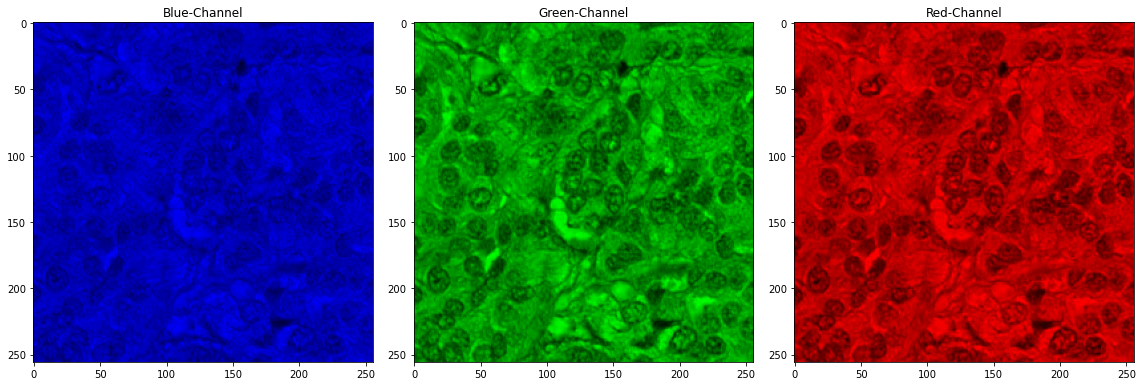

<Figure size 432x288 with 0 Axes>

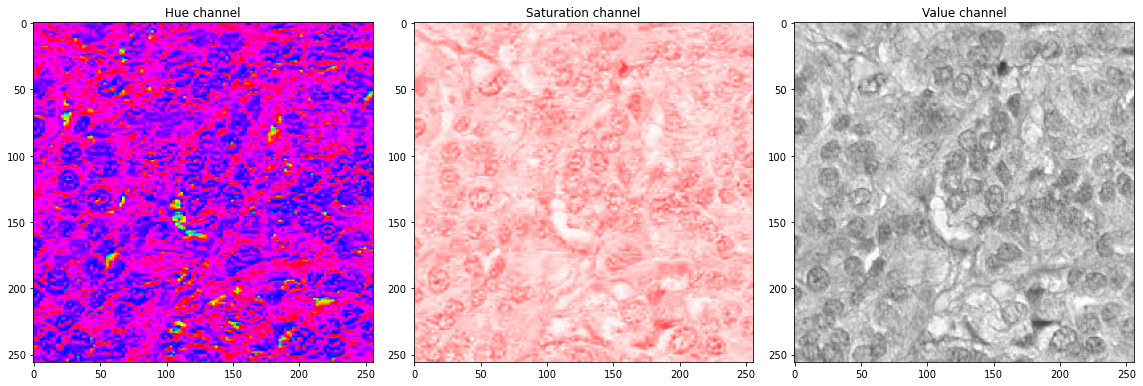

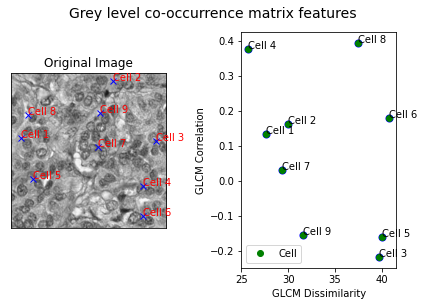

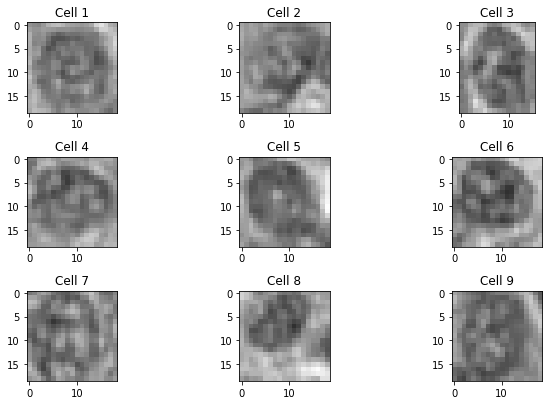

In [7]:
from skimage.color import rgb2hed
import skimage.measure 

no = 809 #number of image
im_rgb = images[no] #choosing image no.809 as our given image
   

#H
im_hed = rgb2hed(im_rgb) #converting image 809 in to the HED-Space
im_h = im_hed[:,:,0] #"h"-channel of image 809
im_h_mean = np.mean(im_h,axis= (0,1)) #mean of H-channel of image 809
im_h_var = np.var(im_h,axis= (0,1)) #mean of H-channel of image 809
im_h_en = skimage.measure.shannon_entropy(im_h) #entropy of H-Channel of iamge 809

print('| Channel\t\t| a. Average\t| b. Variance\t| c. Entropy')
print('-------------------------------------------------------------------------')
print('|\t%s\t\t| %1.3f\t\t| %1.3f\t\t| %1.3f' % ('H', im_h_mean, im_h_var, im_h_en))
"""
# There are 2 ways to calculate the entropy.
# 1. Way, directly through the module scipy.stats:
from scipy import stats
im_h_en = stats.entropy(im_h,axis= (0,1), base=2) #entropy of H-Channel of image 809
# 2. Way, through a count functions - skimage.measure.shannon_entropy uses this method
# - somehow they deliver different results. Entropy(1.Way) = 15.99 whereas Entropy(2.Ways) = 15.164
# through this task I use the second way to obtain comparable results
A, counts = np.unique(im_h, return_counts=True)
ent = stats.entropy(counts, base=2)
"""
channels_rgb = ['Red','Green','Blue']
im_rgb_res = np.zeros((3,3)) #saving the average, variance and the entropy of the red, green and blue channels

for i in range (0,3):
    # for loop runs through each Channel: Where i=2 refers to the blue, i=1 refers to the green and
    # i=0 refers to the red channel - saving the results in im_rgb
    sh = im_rgb[:,:,i]
    im_rgb_res[i,0] = np.mean(sh,axis= (0,1)) #mean of H-channel of image 809
    im_rgb_res[i,1] = np.var(sh,axis= (0,1)) #mean of H-channel of image 809
    im_rgb_res[i,2] = skimage.measure.shannon_entropy(sh) #entropy of H-Channel of image 809
    print('-------------------------------------------------------------------------')
    print('|\t%s\t\t| %1.3f\t| %1.3f\t| %1.3f' % (channels_rgb[i], im_rgb_res[i,0], im_rgb_res[i,1], im_rgb_res[i,2]))


    
#Visulitation of each channel 
import matplotlib.pyplot as plt
fig=plt.figure(figsize=(16,9))
ax1, ax2, ax3 = fig.add_subplot(1, 3, 1), fig.add_subplot(1, 3, 2), fig.add_subplot(1, 3, 3)
imb, img, imr = images[809].copy(), images[809].copy(), images[809].copy()
imb[:, :, 0] = 0
imb[:, :, 1] = 0
ax1.imshow(imb)

img[:, :, 0] = 0
img[:, :, 2] = 0
ax2.imshow(img)

imr[:, :, 1] = 0
imr[:, :, 2] = 0
ax3.imshow(imr)

ax1.set_title('Blue-Channel')
ax2.set_title('Green-Channel')
ax3.set_title('Red-Channel')
fig.tight_layout()
plt.figure()

#d
# =============================================================================
# Now we want to convert our images from RGB-Space to HSV-Space (Hue, Saturation and Value)
# (https://www.tech-faq.com/hsv.html & https://en.wikipedia.org/wiki/HSL_and_HSV for further explanations).
# Hue Channel: representing the colors
# Saturation Channel:  indicating the range of grey in the color space
# Value Channel: parameter for brightness of the color and varies with color saturation
#
# But why the HSV-Space? The HSV colour space is easier to use to filter for specific colours
# compared to the RBG colour space. (This link gives an easy understanding of the topic:https://handmap.github.io/hsv-vs-rgb/).
# For example in our case I want to search for specific violet tones in the images which would be a lot
# in the RGB-space space than in HSV-space.
# The Hue-Channel and Saturation channel have less meaning in our case because our
# images have very similar Saturation and Hue values. The juxtaposition of those channels
# of the HSV-Space underlines my statement due to the Saturation- and Hue Channel does not provide great contrasts
# but the Value-Channel does. The low entropy of the value-channel, which is at the same level as the Blue-Channel,
# clarifies this as well.
# =============================================================================
print('-------------------------------------------------------------------------')
from skimage.color import rgb2hsv, hsv2rgb

im_hsv =  rgb2hsv(im_rgb)
channels_hsv = ['Hue\t','Saturation','Value\t']
im_hsv_res = np.zeros((3,3)) #saving the average, variance and the entropy of the red, green and blue channels

for i in range (0,3):
    # for loop runs through each Channel: Where i=2 refers to the blue, i=1 refers to the green and
    # i=0 refers to the red channel - saving the results in im_rgb
    sh = im_hsv[:,:,i]
    im_hsv_res[i,0] = np.mean(sh,axis= (0,1)) #mean of H-channel of image 809
    im_hsv_res[i,1] = np.var(sh,axis= (0,1)) #mean of H-channel of image 809
    im_hsv_res[i,2] = skimage.measure.shannon_entropy(sh) #entropy of H-Channel of image 809
    print('-------------------------------------------------------------------------')
    print('|\t%s\t| %1.3f\t\t| %1.3f\t\t| %2.3f' % (channels_hsv[i], im_hsv_res[i,0], im_hsv_res[i,1], im_hsv_res[i,2]))

#Visulitation of each channel 
import matplotlib.pyplot as plt

fig=plt.figure(figsize=(16,9))
ax1, ax2, ax3 = fig.add_subplot(1, 3, 1), fig.add_subplot(1, 3, 2), fig.add_subplot(1, 3, 3)

null = np.zeros_like(im_hsv[:, :, 1])
mx = null + 1

ax1.imshow(hsv2rgb(np.stack((im_hsv[:, :, 0], mx, mx), axis=-1)))
ax2.imshow(hsv2rgb(np.stack((null, im_hsv[:, :, 1], mx), axis=-1)))
ax3.imshow(hsv2rgb(np.stack((null, null, im_hsv[:, :, 2]), axis=-1)))

ax1.set_title("Hue channel")
ax3.set_title("Value channel")
ax2.set_title("Saturation channel")

fig.tight_layout()



from sklearn.decomposition import IncrementalPCA
from skimage.color import rgb2gray

im_grey = rgb2gray(images)
print('-------------------------------------------------------------------------')
print('|\t%s\t\t| %1.3f\t\t| %1.3f\t\t| %1.3f' % ('Grey', np.mean(im_grey[no],axis= (0,1)), np.var(im_grey[no],axis= (0,1)), skimage.measure.shannon_entropy(im_grey[no])))

ipca = IncrementalPCA()
im_greyfl = np.zeros((len(im_grey),256**2))
for i in range (0,len(im_grey)):
    im_greyfl[i] = im_grey[i,:,:].flatten()
ipca.partial_fit(im_greyfl[1:500,:])



from skimage.feature import greycomatrix, greycoprops
from skimage import data
from skimage import util


# =============================================================================
# Sources:[1] https://www.researchgate.net/publication/312107023_Extraction_of_Texture_Features_using_GLCM_and_Shape_Features_using_Connected_Regions
#         [2] https://scikit-image.org/docs/dev/auto_examples/features_detection/plot_glcm.html
#         [3] https://support.echoview.com/WebHelp/Windows_and_Dialog_Boxes/Dialog_Boxes/Variable_properties_dialog_box/Operator_pages/GLCM_Texture_Features.htm
#         [4] https://prism.ucalgary.ca/bitstream/handle/1880/51900/texture%20tutorial%20v%203_0%20180206.pdf?sequence=11&isAllowed=y
#
# "[...]GLCM (Gray-Level-Co-Occurance Matrix) represents the relation between reference  pixel (i) 
# and neighbour pixel (j) in various orientation. Initially, the value of each element in GLCM (i,j) is zero.
# The value of each element is updated as per occurrence of pixels together. Texture features calculated using 
# GLCM are Contrast, Correlation, Dissimilarity, Energy, Entropy, Homogeneity, Mean, Variance, Standard Deviation.[...]" [3]
# Many of the features mentioned above say the same thing at their core. It is mainly about the distance,
# difference or deviation between the grey levels. Therefore, as in source [2],
# I see correlation and dissimilarity as interesting features.
#
#
# =============================================================================
im_grey = rgb2gray(images[809])
im_grey = util.img_as_ubyte(im_grey)

PATCH_SIZE = 19

# select some patches from sky areas of the image
cell_locations = [(17, 108), (169, 14), (240, 113), (218, 186), (36, 175), (218,236), (143,123), (28,70), (146,67)]
cell_patches = []
for loc in cell_locations:
    cell_patches.append(im_grey[loc[1]:loc[1] + PATCH_SIZE,
                             loc[0]:loc[0] + PATCH_SIZE])


#compute some GLCM properties each patch
xs = []
ys = []
for patch in cell_patches:
    glcm = greycomatrix(patch, distances=[5], angles=[0], levels=256,
                        symmetric=True, normed=True)
    xs.append(greycoprops(glcm, 'dissimilarity')[0, 0])
    ys.append(greycoprops(glcm, 'correlation')[0, 0])
   
# create the figure
fig = plt.figure()

# display original image with locations of patches
ax = fig.add_subplot(1, 2, 1)
ax.imshow(im_grey, cmap=plt.cm.gray,
          vmin=0, vmax=255)

for i,(x, y) in enumerate(cell_locations):
    ax.plot(x, y, 'x', color='blue')
    ax.annotate('Cell %d' % (i + 1), xy=(x, y), fontsize=10, color='red')
    
ax.set_title('Original Image')
ax.set_xticks([])
ax.set_yticks([])
ax.axis('image')
"""
# create the figure
plt.figure()

# display original image with locations of patches
plt.imshow(im_grey, cmap=plt.cm.gray,
          vmin=0, vmax=255)

for (y, x) in cell_locations:
    plt.plot(x + PATCH_SIZE / 2, y + PATCH_SIZE / 2, 'bs')
"""    
# for each patch, plot (dissimilarity, correlation)
ax = fig.add_subplot(1, 2, 2)
ax.plot(xs[:len(cell_patches)],  ys[:len(cell_patches)], 'go',
        label='Cell')
ax.set_xlabel('GLCM Dissimilarity')
ax.set_ylabel('GLCM Correlation')
ax.legend()

for i in range (0,len(cell_patches)):
    ax.scatter(xs[i], ys[i], 50, color ='blue')
    ax.annotate('Cell %d' % (i + 1), xy=(xs[i], ys[i]), fontsize=10)    
fig.tight_layout()
fig.suptitle('Grey level co-occurrence matrix features', fontsize=14, y=1.05)
plt.show()

fig = plt.figure(figsize=(9, 9))
cal = 1+round(len(cell_patches)/3+0.5)

# display the image patches
for i, patch in enumerate(cell_patches):
    ax = fig.add_subplot(cal, 3, 4 + i)
    ax.imshow(patch, cmap=plt.cm.gray,
              vmin=0, vmax=255)
    ax.set_title('Cell %d' % (i + 1))


# display the patches and plot
fig.tight_layout()
plt.show()



|Corr. coefficients	| H-channel	| Red-channel	| Green-channel	| Blue-channel	| Value-channel	|
---------------------------------------------------------------------------------------------------------
| Average		| 0.4448	| -0.4445	| -0.2816	| -0.2634	| -0.4293	|
---------------------------------------------------------------------------------------------------------
| Variance		| 0.0775	| 0.0959	| 0.1365	| 0.0920	| 0.0729	|
---------------------------------------------------------------------------------------------------------
| Entropy		| 0.0051	| 0.1945	| 0.0901	| 0.0869	| 0.1592	|


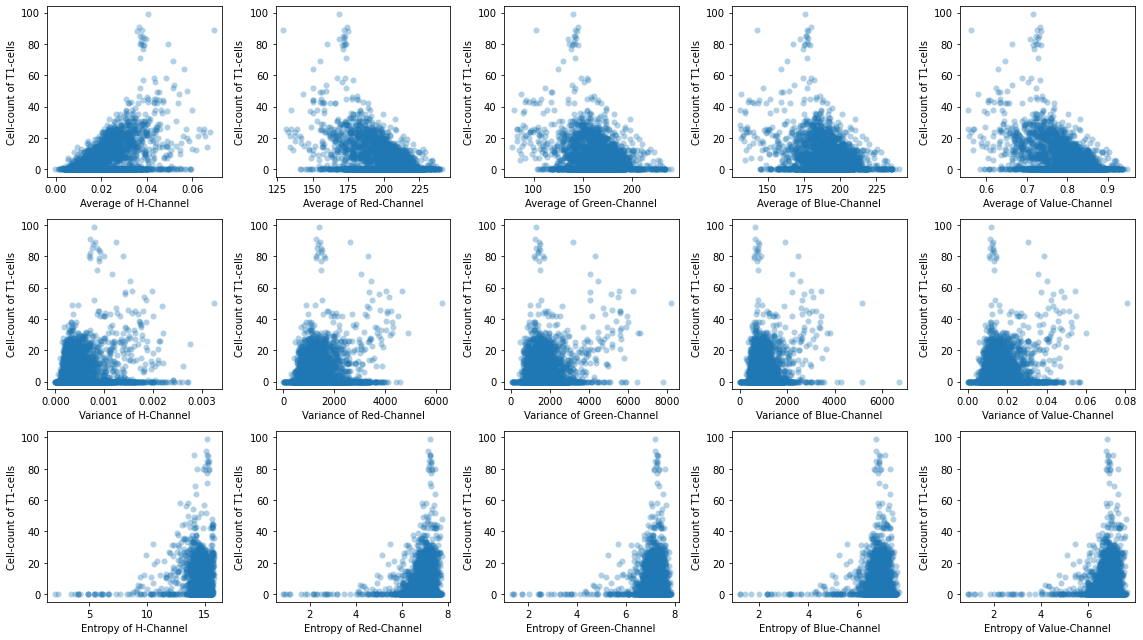

In [3]:
def featuremem(imgs):
    memory = np.zeros((len(imgs),5,3)) #the results are getting saved here
    for j,im in enumerate(imgs):    #runs through evry image
        memory[j,0,0] = np.mean(rgb2hed(im)[:,:,0],axis= (0,1)) #mean of H-channel of image j
        memory[j,0,1] = np.var(rgb2hed(im)[:,:,0],axis= (0,1)) #mean of H-channel of image j
        memory[j,0,2] = skimage.measure.shannon_entropy(rgb2hed(im)[:,:,0]) #entropy of H-Channel of image j
        for i in range (0,3):
            # cf. 
            # runs through the Red, Blue and Green Channel
            memory[j,i+1,0] = np.mean(im[:,:,i],axis= (0,1)) #mean of channel of image j
            memory[j,i+1,1] = np.var(im[:,:,i],axis= (0,1)) #mean of channel of image j
            memory[j,i+1,2] = skimage.measure.shannon_entropy(im[:,:,i]) #entropy of H-Channel of image j
        memory[j,4,0] = np.mean(rgb2hsv(im)[:,:,2],axis= (0,1)) #mean of Value-channel of image j
        memory[j,4,1] = np.var(rgb2hsv(im)[:,:,2],axis= (0,1)) #mean of Value-channel of image j
        memory[j,4,2] = skimage.measure.shannon_entropy(rgb2hsv(im)[:,:,2]) #entropy of Value-Channel of image j
    return memory

memory = featuremem(images)

fig=plt.figure(figsize=(16,9))
features = ['Average','Variance','Entropy']
channels = ['H','Red','Green','Blue','Value']
print('|Corr. coefficients\t| H-channel\t| Red-channel\t| Green-channel\t| Blue-channel\t| Value-channel\t|')
for i,mem in enumerate(memory.T):
    coef = np.zeros((1,5))
    for j in range (0,5):
        ax = fig.add_subplot(3, 5, j+i*5+1)
        coef[:,j] = np.corrcoef(counts[:,0],mem[j])[0,1]
        #print('The correlation coefficient of the %s of %s-Channel = %1.4f' % (features[i],
                                                                      # channels[j]
                                                                      #,np.corrcoef(mem[j],counts[:,0])[0,1]))
        ax.scatter( mem[j], counts[:,0],linewidths=0.01, alpha=0.34)
        #ax.set_title('%s of %s-Channel vs cell count of T1-cells' % (features[i], channels[j]))
        ax.set_xlabel('%s of %s-Channel' % (features[i], channels[j]))
        ax.set_ylabel('Cell-count of T1-cells')
    print('---------------------------------------------------------------------------------------------------------')
    print('| %s\t\t| %1.4f\t| %1.4f\t| %1.4f\t| %1.4f\t| %1.4f\t|' % (features[i], coef[:,0], coef[:,1],
                                                           coef[:,2], coef[:,3], coef[:,4]))
fig.tight_layout() 

### Which features are important?
You should focus on features with high absolute correlation coefficients like the average here. A high absolute correlation coefficient gives us a certain confidence that the two variables are linearly dependant. This knowledge could help us to predict the cell count of unseen images. A positive/negative correlation coefficient states out that if there is a positive increase in one variable, there is also a positive/negative change in the second variable. In our case, the H-Channel or the Red-Channel have a big enough value to claim that there exists a linear dependency between the cell-count and the averages of the respective channels. Namely around |0.45|. If I had to choose between those two channels I would choose the red-channel due to the halftimes lower entropy. The lower the entropy the more information we can expect in a set of values.

### ii)

#### a. Ordinary Least Squares (OLS) regression

| Model: OLS	| RMSE		| Pearsons Corr. Coeff.	| Spearmans Corr. Coeff.| R2 score	|
-----------------------------------------------------------------------------------------------
| Average	| 9.9400	| 0.5809		| 0.5754		| 0.3116	|
-----------------------------------------------------------------------------------------------
| Variance	| 11.8771	| 0.2216		| 0.1135		| 0.0406	|
-----------------------------------------------------------------------------------------------
| Entropy	| 10.8335	| 0.4572		| 0.4222		| 0.1855	|


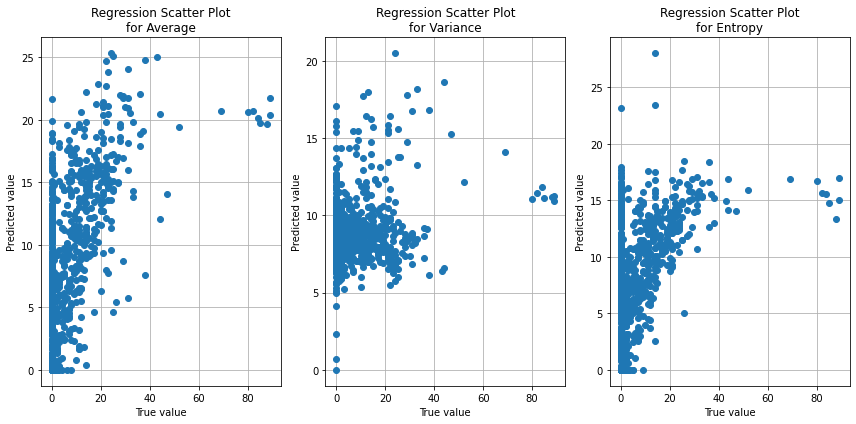

In [9]:
from sklearn import linear_model, metrics
from scipy import stats

X1 = images[folds == 1] #Using the 2nd Fold for validation (Fold = 1)
Y1 = counts[folds == 1]

memory0 = featuremem(X0)
memory1 = featuremem(X1)


ols = linear_model.LinearRegression(fit_intercept=True)

features = ['Average','Variance','Entropy']
print('| Model: OLS\t| RMSE\t\t| Pearsons Corr. Coeff.\t| Spearmans Corr. Coeff.| R2 score\t|')

fig=plt.figure(figsize=(12,6))

for i in range (0,3):
    ols.fit(memory0[:,:,i], Y0[:,0]) #fitting with Training fold
    pred = ols.predict(memory1[:,:,i]) #prediction on Validation fold
    pred[pred<0] = 0 #values lower than zero would make no sense
    ax = fig.add_subplot(1,3,i+1)
    ax.plot(Y1[:,0], pred,'o');ax.grid();ax.set_xlabel('True value');ax.set_ylabel('Predicted value');ax.set_title('Regression Scatter Plot\nfor %s' % features[i])
    print('-----------------------------------------------------------------------------------------------')
    print('| %s\t| %1.4f\t| %1.4f\t\t| %1.4f\t\t| %1.4f\t|' % (features[i],np.sqrt(metrics.mean_squared_error(Y1[:,0], pred)), #Root of MSE
                                                            stats.pearsonr(Y1[:,0], pred)[0], #Pearsons C.C.
                                                            stats.spearmanr(Y1[:,0], pred)[0], #Spearmans C.C.
                                                            ols.score(memory1[:,:,i], Y1[:,0]))) #R^2
fig.tight_layout()

#### b. Multilayer Perceptron (in Sklearn or Keras or PyTorch).

TF-Version: 2.4.1
Num GPUs available: 0
KERAS
| Model: MLP	| RMSE		| Pearsons Corr. Coeff.	| Spearmans Corr. Coeff.| R2 score	|
-----------------------------------------------------------------------------------------------
| Average	| 10.6813	| 0.5075		| 0.4876		| 0.2253	|
-----------------------------------------------------------------------------------------------
| Variance	| 11.9266	| 0.1932		| 0.1246		| 0.0341	|
-----------------------------------------------------------------------------------------------
| Entropy	| 11.0983	| 0.4120		| 0.3887		| 0.1636	|
SKLEARN
| Model: MLP	| RMSE		| Pearsons Corr. Coeff.	| Spearmans Corr. Coeff.| R2 score	|
-----------------------------------------------------------------------------------------------
| Average	| 10.4240	| 0.5268		| 0.4920		| 0.2591	|
-----------------------------------------------------------------------------------------------
| Variance	| 12.6762	| 0.2383		| 0.3046		| -0.1311	|
--------------------------------------------

<function matplotlib.pyplot.show(close=None, block=None)>

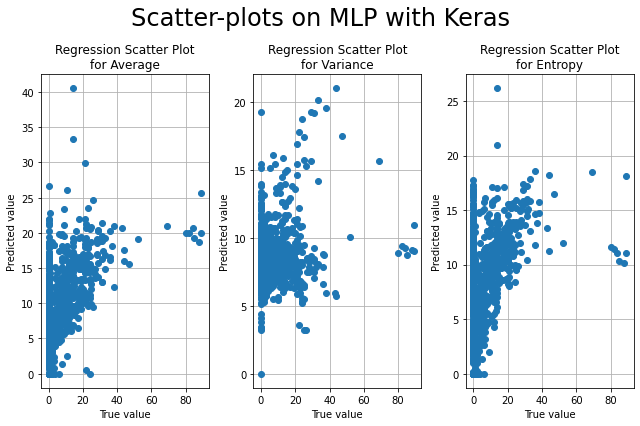

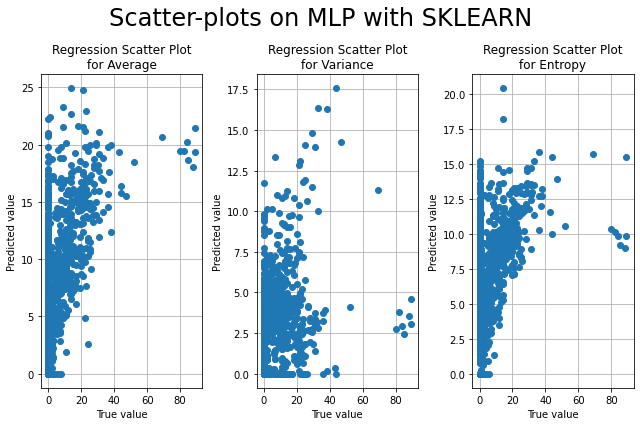

In [19]:
# USING KERAS - did not work as expected 
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.layers.experimental import preprocessing


print('TF-Version:', tf.__version__)
A = tf.config.experimental.list_physical_devices('GPU')
print('Num GPUs available:', len(A))


"""
#preprocessing data
norm0 = preprocessing.Normalization()
norm0.adapt(np.array(memory0))
"""
fig1=plt.figure(figsize=(9,6))
plt.suptitle('Scatter-plots on MLP with Keras', fontsize='24')
print('KERAS')
print('| Model: MLP\t| RMSE\t\t| Pearsons Corr. Coeff.\t| Spearmans Corr. Coeff.| R2 score\t|')
for i in range (0,3):
    n_features = memory0.shape[1]
    model = Sequential()
    #model.add(preprocessing.Normalization()) #uncomment for preprocessing - seems to have no impact
    model.add(tf.keras.Input(shape=(n_features,)))
    model.add(Dense(units = 4,activation='linear', kernel_initializer='identity'))
    model.add(Dense(units = 827,activation='linear', kernel_initializer='RandomUniform'))
    model.add(Dense(units = 1,activation='linear', kernel_initializer='RandomUniform')) #excludes values lower than zero!
    
    model.compile(loss = 'mse',optimizer=Adam(learning_rate = 0.0001),metrics=['accuracy'])
    history = model.fit(memory0[:,:,i], Y0[:,0], epochs = 1000, shuffle = True,
                        batch_size = 46, verbose = 0)    
    pred = model.predict(memory1[:,:,i])
    pred[pred<0] = 0
    ax = fig1.add_subplot(1,3,i+1)
    ax.plot(Y1[:,0], pred,'o');ax.grid();ax.set_xlabel('True value');ax.set_ylabel('Predicted value');ax.set_title('Regression Scatter Plot\nfor %s' % features[i])
    pred = np.reshape(pred,(len(pred),))
    print('-----------------------------------------------------------------------------------------------')
    print('| %s\t| %1.4f\t| %1.4f\t\t| %1.4f\t\t| %1.4f\t|' % (features[i],np.sqrt(metrics.mean_squared_error(Y1[:,0], pred)), #Root of MSE
                                                            stats.pearsonr(Y1[:,0], pred)[0], #Pearsons C.C.
                                                            stats.spearmanr(Y1[:,0], pred)[0], #Spearmans C.C.
                                                            metrics.r2_score(Y1[:,0], pred))) #R^2
fig1.tight_layout()
plt.show

# =============================================================================
# I found it very difficult to set up a neural network with the right parameters to get good results.
# Additionally, I have to mention that my device has no GPU and took very long to calculate optimizing the network.
# After several experiments, I switched over to sklearn and tried my luck there.
# The results are very similar
# =============================================================================

#USING SKLEARN
from sklearn.neural_network import MLPRegressor

fig=plt.figure(figsize=(9,6))
plt.suptitle('Scatter-plots on MLP with SKLEARN', fontsize='24')

print('SKLEARN')
print('| Model: MLP\t| RMSE\t\t| Pearsons Corr. Coeff.\t| Spearmans Corr. Coeff.| R2 score\t|')

for i in range (0,3):
    regr = MLPRegressor(batch_size=1, max_iter = 1000, verbose=0) #default: activation=’relu’, solver=’adam’, shuffle = True
    regr.fit(memory0[:,:,i], Y0[:,0])
    pred = regr.predict(memory1[:,:,i])
    pred[pred<0] = 0
    ax = fig.add_subplot(1,3,i+1)
    ax.plot(Y1[:,0], pred,'o');ax.grid();ax.set_xlabel('True value');ax.set_ylabel('Predicted value');ax.set_title('Regression Scatter Plot\nfor %s' % features[i])
    print('-----------------------------------------------------------------------------------------------')
    print('| %s\t| %1.4f\t| %1.4f\t\t| %1.4f\t\t| %1.4f\t|' % (features[i],np.sqrt(metrics.mean_squared_error(Y1[:,0], pred)), #Root of MSE
                                                            stats.pearsonr(Y1[:,0], pred)[0], #Pearsons C.C.
                                                            stats.spearmanr(Y1[:,0], pred)[0], #Spearmans C.C.
                                                            regr.score(memory1[:,:,i], Y1[:,0]))) #R^2

fig.tight_layout()
plt.show

Note: 
- The R^2-Score for Variance (using sklearn) is negative which means the model does not follow the trend of the data, so fits worse than a horizontal line.

#### c. Support Vector Regression

| Model: MLP	| RMSE		| Pearsons Corr. Coeff.	| Spearmans Corr. Coeff.| R2 score	|


C:\Users\Felipe\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:668: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  % (min_groups, self.n_splits)), UserWarning)


The best parameters: {'svr__C': 5, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 0.001, 'svr__gamma': 0.1, 'svr__kernel': 'poly'}
-----------------------------------------------------------------------------------------------
| Average	| 10.1522	| 0.5729		| 0.6081		| 0.2998	|


C:\Users\Felipe\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:668: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  % (min_groups, self.n_splits)), UserWarning)


The best parameters: {'svr__C': 5, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 0.1, 'svr__gamma': 0.1, 'svr__kernel': 'poly'}
-----------------------------------------------------------------------------------------------
| Variance	| 11.8468	| 0.2923		| 0.4417		| 0.0356	|


C:\Users\Felipe\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:668: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  % (min_groups, self.n_splits)), UserWarning)


The best parameters: {'svr__C': 5, 'svr__coef0': 0, 'svr__degree': 2, 'svr__epsilon': 0.001, 'svr__gamma': 0.1, 'svr__kernel': 'rbf'}
-----------------------------------------------------------------------------------------------
| Entropy	| 10.5401	| 0.5233		| 0.5252		| 0.2443	|


<function matplotlib.pyplot.show(close=None, block=None)>

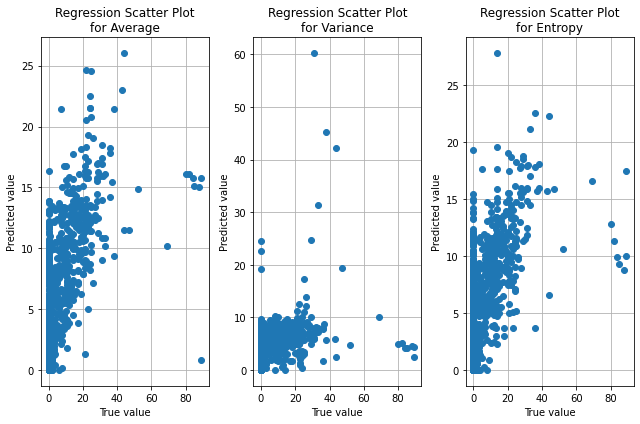

In [23]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import StratifiedKFold

# =============================================================================
# Here I used a pipeline to get the “best”, among my parameter set,
# hyperparameters to optimize the mean squared error. The pipeline includes standardization of the feature space as well as
# the optimal kernel choice. The hyperparameter sets are to be read from the variable searchpara.
# =============================================================================


fig=plt.figure(figsize=(9,6))
skf = StratifiedKFold(shuffle = True, n_splits = 5)
print('| Model: MLP\t| RMSE\t\t| Pearsons Corr. Coeff.\t| Spearmans Corr. Coeff.| R2 score\t|')
for i in range (0,3):
    svr = SVR()
    pipe = Pipeline(steps=[('scale', StandardScaler()),('svr', svr)])
    searchpara = [{'svr__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
                   'svr__gamma': [1e-3, 1e-1], 'svr__C': [0.001, 0.1, 1, 3, 5],
                   'svr__coef0':[0,1], 'svr__epsilon':[0.1, 0.01, 0.001],
                   'svr__degree':[2,3,0.5]}]
    
    estimator = GridSearchCV(pipe, searchpara, scoring='neg_mean_squared_error', cv= skf, n_jobs=-1, verbose= 0)
    estimator.fit(memory0[:,:,i], Y0[:,0])
    print("The best parameters: {0}".format(estimator.best_params_))
    pipe.set_params(**estimator.best_params_)
    pipe.fit(memory0[:,:,i], Y0[:,0])
    pred = pipe.predict(memory1[:,:,i])
    pred[pred<0] = 0
    ax = fig.add_subplot(1,3,i+1)
    ax.plot(Y1[:,0], pred,'o');ax.grid();ax.set_xlabel('True value');ax.set_ylabel('Predicted value');ax.set_title('Regression Scatter Plot\nfor %s' % features[i])
    print('-----------------------------------------------------------------------------------------------')
    print('| %s\t| %1.4f\t| %1.4f\t\t| %1.4f\t\t| %1.4f\t|' % (features[i],np.sqrt(metrics.mean_squared_error(Y1[:,0], pred)), #Root of MSE
                                                            stats.pearsonr(Y1[:,0], pred)[0], #Pearsons C.C.
                                                            stats.spearmanr(Y1[:,0], pred)[0], #Spearmans C.C.
                                                            pipe.score(memory1[:,:,i], Y1[:,0]))) #R^2
fig.tight_layout()
plt.show

In [26]:
import dill #saving the variables of the kernel #safty first
dill.dumb_session('PickleAssignment2.db')

## Question 3

### a.

In [2]:
#%% Import Moduls and packages
# Many are unused but are still mentioned as i want to make spontaneous changes
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" #disable GPU - I do not have one on my device!!

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense, Dropout, Flatten, BatchNormalization, Conv2D, MaxPool2D, AveragePooling2D, experimental, LocallyConnected2D
from keras.callbacks import History 
import tensorflow_addons as tfa
from tensorflow_addons.layers import Maxout
from tensorflow.keras import callbacks
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.metrics import categorical_crossentropy #unused
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers.experimental import preprocessing
from tensorflow.keras.models import Model
from tensorflow.nn import pool
import glob
import itertools
import shutil
import random
import warnings
import matplotlib.pyplot as plt
from skimage.color import rgb2hed, rgb2hsv
from sklearn import metrics
from scipy import stats

TensorFlow Version: 2.4.1
Num GPUs available: 0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

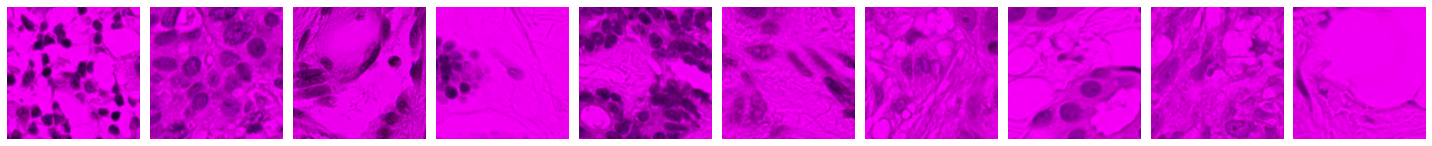

In [3]:
#%% Data Preprocessing

def mypreprocessor(image): #using the the analysis of ii) to preprocess  
    image[:,:,1] = rgb2hed(image)[:,:,0]; image[:,:,2] = rgb2hsv(image)[:,:,2]; image[:,:,0] = image[:,:,0]
    return image*(1./255)

# =============================================================================
# Here I thought it might be useful to preprocess the data based on our finding in question 2 and rescaled it such that
# the pixel values are between 0 and 1. In the pictures shown below, the cells have been clearly crystallised,
# so I assumed that my CNN would have an easier time handling the pictures.
# =============================================================================


#%%
warnings.filterwarnings("ignore", category=FutureWarning) #ignore warnings for the first to keep everythin clear and to
                                  #avoid unnecessary "spam".

print('TensorFlow Version:', tf.__version__) #Checking TF-Version
A = tf.config.experimental.list_physical_devices('GPU')
print('Num GPUs available:', len(A)) #asking for available GPUs

# other preprocessing methods
# layers.experimental.preprocessing.Rescaling(1./255)
# preprocessing_function= tf.keras.applications.vgg16.preprocess_input
# use mypreprocessor

#Processing our data according to our Folds. 
batch_size = 32 #default batch size for a reason: A good tradeoff between convergence speed and noise
train_batches = ImageDataGenerator(preprocessing_function= mypreprocessor)\
    .flow(X0, Y0[:,0], batch_size = batch_size)
val_batches = ImageDataGenerator(preprocessing_function= mypreprocessor)\
    .flow(X1,  Y1[:,0], batch_size = batch_size)
test_batches = ImageDataGenerator(preprocessing_function= mypreprocessor)\
    .flow(X2,  Y2[:,0], batch_size = batch_size, shuffle=False)
    
imgs, labels = next(train_batches)

def plotImages(images_arr): #showing 10 preprocessed images with the accoring preprocess function. Here: mypreprocessor
     fig2, axes = plt.subplots(1, 10, figsize=(20,20))
     axes = axes.flatten()
     for img, ax in zip( images_arr, axes):
         ax.imshow(img)
         ax.axis('off')
     plt.tight_layout()
     plt.show()

plotImages(imgs)

In [7]:
print('#Batches',len(train_batches))
#%% Representation
# =============================================================================
# It is hard to justify here my selection on layers and filter as a great deal has come about through expirmentation
# and this partly by chance.
# =============================================================================


inputshape = X0[0,:,:,:].shape
model = Sequential()

#Representation
model.add(Conv2D(filters = 32, kernel_size=(5, 5), input_shape = inputshape, activation='relu', #1st hidden layer
                 padding = 'same'))
model.add(BatchNormalization(epsilon=0.0001))
model.add(MaxPool2D(pool_size=(2, 2), strides=2)) #2n hidden layer
model.add(Conv2D(filters = 64, kernel_size=(5, 5), activation='relu', #3rd hidden layer
                 padding = 'same'))
model.add(MaxPool2D(pool_size=(2, 2), strides=2)) #4th hidden layer
model.add(Conv2D(filters = 128, kernel_size=(3, 3), activation='relu', #5th hidden layer
                 padding = 'same'))
model.add(MaxPool2D(pool_size=(2, 2), strides=2))
model.add(Maxout(num_units = 128))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(1))
model.summary()

#Batches 26
Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_6 (Conv2D)            (None, 256, 256, 32)      2432      
_________________________________________________________________
batch_normalization_2 (Batch (None, 256, 256, 32)      128       
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (None, 128, 128, 32)      0         
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 128, 128, 64)      51264     
_________________________________________________________________
max_pooling2d_7 (MaxPooling2 (None, 64, 64, 64)        0         
_________________________________________________________________
conv2d_8 (Conv2D)            (None, 64, 64, 128)       73856     
_________________________________________________________________
max_pooling2d_8 (MaxPooling2 (None, 32, 32

In [8]:
#%%Optimitazion

epochs = 100
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, min_delta = 1, mode='min')# baseline = 130)

model.compile(loss = 'mse', optimizer=Adam(learning_rate = 0.0001), metrics=['accuracy'])
history = model.fit(x = train_batches, validation_data = val_batches, epochs = epochs, shuffle = True,
                    verbose = 2, callbacks = [callback], steps_per_epoch = len(train_batches),
                    validation_steps = len(val_batches))    

print('termination after ',len(history.history['loss']), ' epochs')  # Only 4 epochs are run.

Epoch 1/100
26/26 - 98s - loss: 134.3284 - accuracy: 0.0435 - val_loss: 208.0773 - val_accuracy: 0.3939
Epoch 2/100
26/26 - 121s - loss: 92.6685 - accuracy: 0.0423 - val_loss: 204.8102 - val_accuracy: 0.3778
Epoch 3/100
26/26 - 133s - loss: 61.4787 - accuracy: 0.0593 - val_loss: 201.1252 - val_accuracy: 0.3351
Epoch 4/100
26/26 - 140s - loss: 41.9044 - accuracy: 0.0544 - val_loss: 206.1401 - val_accuracy: 0.3899
Epoch 5/100
26/26 - 146s - loss: 30.8856 - accuracy: 0.0653 - val_loss: 199.2738 - val_accuracy: 0.3471
Epoch 6/100
26/26 - 156s - loss: 29.6494 - accuracy: 0.0883 - val_loss: 193.3409 - val_accuracy: 0.3084
Epoch 7/100
26/26 - 155s - loss: 25.8675 - accuracy: 0.1173 - val_loss: 184.1533 - val_accuracy: 0.1976
Epoch 8/100
26/26 - 177s - loss: 17.8229 - accuracy: 0.1245 - val_loss: 175.5073 - val_accuracy: 0.1709
Epoch 9/100
26/26 - 157s - loss: 12.7136 - accuracy: 0.1185 - val_loss: 171.1289 - val_accuracy: 0.1602
Epoch 10/100
26/26 - 154s - loss: 10.4983 - accuracy: 0.1258 - v

"\n#%% VGG16 Representation\nvgg16model = tf.keras.applications.vgg16.VGG16(include_top=False, input_shape=(256,256,3))#include_top=False, input_shape=(256,256,3))\n#vgg16model.summary()\n\nmodel = Sequential()\nfor layer in vgg16model.layers[:-1]:\n    model.add(layer)\n    \n#model.summary() #same as vgg16model without last layer, we want only a single output there\n\n\nfor layer in model.layers:\n    layer.trainable = False\n    \nmodel.add(Flatten())\n#model.add(Dense(256, activation='relu'))\nmodel.add(Dense(1))\n#model.add(Dense(1, activation=('relu')))\nmodel.summary()\n\n#%% VGG16 Optimization\nepochs = 5\n\nmodel.compile(loss = 'mse', optimizer=Adam(learning_rate = 0.0001), metrics=['accuracy'])\nhistory = model.fit(x = train_batches, validation_data = val_batches, epochs = epochs, shuffle = True,\n                    verbose = 2, steps_per_epoch = len(train_batches),\n                    validation_steps = len(val_batches))\n"

| Model: CNN	| RMSE		| Pearsons Corr. Coeff.	| Spearmans Corr. Coeff.| R2 score	|
------------------------------------------------------------------------------------------------
| 		| 8.931		| 0.6118		| 0.537			| 0.370	|


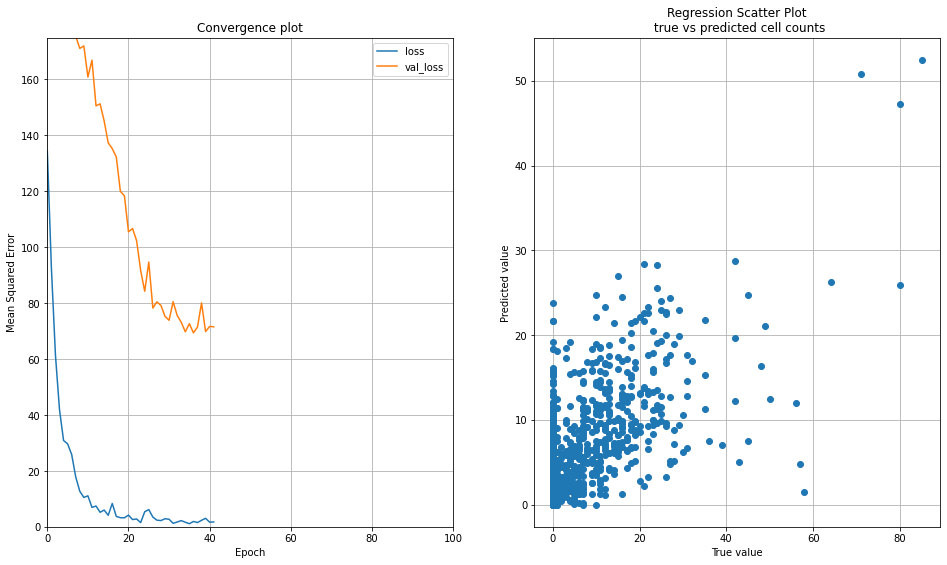

In [10]:
#%%Evaluation
fig= plt.figure(figsize=(16,9))


#Convergence plot
ax = fig.add_subplot(1,2,1)
ax.plot(history.history['loss'], label='loss'); ax.plot(history.history['val_loss'], label='val_loss')
ax.set_title('Convergence plot'); ax.set_xlim([0, epochs]); ax.set_ylim([0, 175]); ax.set_xlabel('Epoch')
ax.set_ylabel('Mean Squared Error'); ax.legend(); ax.grid(True)

#Scatter plot
ax = fig.add_subplot(1,2,2)
pred = model.predict(x= test_batches, verbose=0)
pred[pred<0] = 0 #prevend values lower than zero and set those to zero
ax.plot(Y2[:,0], pred,'o');ax.grid();ax.set_xlabel('True value');ax.set_ylabel('Predicted value');
ax.set_title('Regression Scatter Plot\n true vs predicted cell counts')

#Metrics
pred = np.reshape(pred,(len(pred),))
print('| Model: CNN\t| RMSE\t\t| Pearsons Corr. Coeff.\t| Spearmans Corr. Coeff.| R2 score\t|')
print('------------------------------------------------------------------------------------------------')
print('| \t\t| %1.3f\t\t| %1.4f\t\t| %1.3f\t\t\t| %1.3f\t\t|' % (np.sqrt(metrics.mean_squared_error(Y2[:,0], pred)),
                                                            stats.pearsonr(Y2[:,0], pred)[0],
                                                            stats.spearmanr(Y2[:,0], pred)[0],
                                                            metrics.r2_score(Y2[:,0], pred)))


In [3]:
# =============================================================================
# The result of my self-made CNN did not satisfy me and I had a hard time aligning the layers as efficiently and
# optimally as possible. That's why I decided to change my mind and, as mentioned in the lecture, use an already trained CNN
# and only fine-tune it. And lo and behold, it worked
# After trying and failing to fine-tune VGG16 and VGG19, I have settled on MobileNet.
# tf.keras.applications.mobilet processes and formats the given images into the same
# format as MobileNet was trained with.
# =============================================================================

#Pre-processing
batch_size = 32
train_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input).flow(
    X0, Y0[:,0], batch_size = batch_size)
valid_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input).flow(
    X1, Y1[:,0], batch_size = batch_size)
test_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input).flow(
    X2, Y2[:,0], batch_size = batch_size, shuffle=False)

#Representation
mobile = tf.keras.applications.mobilenet.MobileNet()

x = mobile.layers[-6].output
output = Dense(units=1, activation='relu')(x)
model = Model(inputs=mobile.input, outputs=output)

for layer in model.layers[:-23]: #Amount of layers we want to train!
    layer.trainable = False
   
model.summary()
# Optimization, with Callback which gets triggered if the validation loss does not change signifantly after 7 epochs.
# Signifcant would be a step larger than 1 here
epochs = 50
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, min_delta = 1, mode='min')# baseline = 130)
model.compile(optimizer=Adam(lr=0.0001), loss='mse', metrics=['accuracy'])
history = model.fit(x=train_batches,
            steps_per_epoch=len(train_batches),
            validation_data=valid_batches,
            validation_steps=len(valid_batches),
            epochs=epochs, callbacks = [callback], verbose=2)



Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
conv1 (Conv2D)               (None, 112, 112, 32)      864       
_________________________________________________________________
conv1_bn (BatchNormalization (None, 112, 112, 32)      128       
_________________________________________________________________
conv1_relu (ReLU)            (None, 112, 112, 32)      0         
_________________________________________________________________
conv_dw_1 (DepthwiseConv2D)  (None, 112, 112, 32)      288       
_________________________________________________________________
conv_dw_1_bn (BatchNormaliza (None, 112, 112, 32)      128       
_________________________________________________________________
conv_dw_1_relu (ReLU)        (None, 112, 112, 32)      0     

Epoch 1/50
26/26 - 42s - loss: 181.9369 - accuracy: 0.3035 - val_loss: 125.1701 - val_accuracy: 0.3511
Epoch 2/50
26/26 - 55s - loss: 93.0413 - accuracy: 0.2793 - val_loss: 69.5497 - val_accuracy: 0.3511
Epoch 3/50
26/26 - 58s - loss: 55.7241 - accuracy: 0.2648 - val_loss: 80.2676 - val_accuracy: 0.3939
Epoch 4/50
26/26 - 61s - loss: 35.4055 - accuracy: 0.2539 - val_loss: 111.4311 - val_accuracy: 0.3979
Epoch 5/50
26/26 - 63s - loss: 27.4881 - accuracy: 0.2563 - val_loss: 98.4848 - val_accuracy: 0.3979
Epoch 6/50
26/26 - 66s - loss: 20.6846 - accuracy: 0.2660 - val_loss: 91.4309 - val_accuracy: 0.3979
Epoch 7/50
26/26 - 67s - loss: 15.8244 - accuracy: 0.2769 - val_loss: 65.5335 - val_accuracy: 0.3965
Epoch 8/50
26/26 - 73s - loss: 11.5615 - accuracy: 0.2890 - val_loss: 56.5072 - val_accuracy: 0.3979
Epoch 9/50
26/26 - 65s - loss: 12.9584 - accuracy: 0.2926 - val_loss: 39.5534 - val_accuracy: 0.3832
Epoch 10/50
26/26 - 64s - loss: 9.3586 - accuracy: 0.2902 - val_loss: 33.1377 - val_accu

| Model: CNN	| RMSE		| Pearsons Corr. Coeff.	| Spearmans Corr. Coeff.| R2 score	|
--------------------------------------------------------------------------------------------------
| 		| 5.592		| 0.8707		| 0.827			| 0.753		|


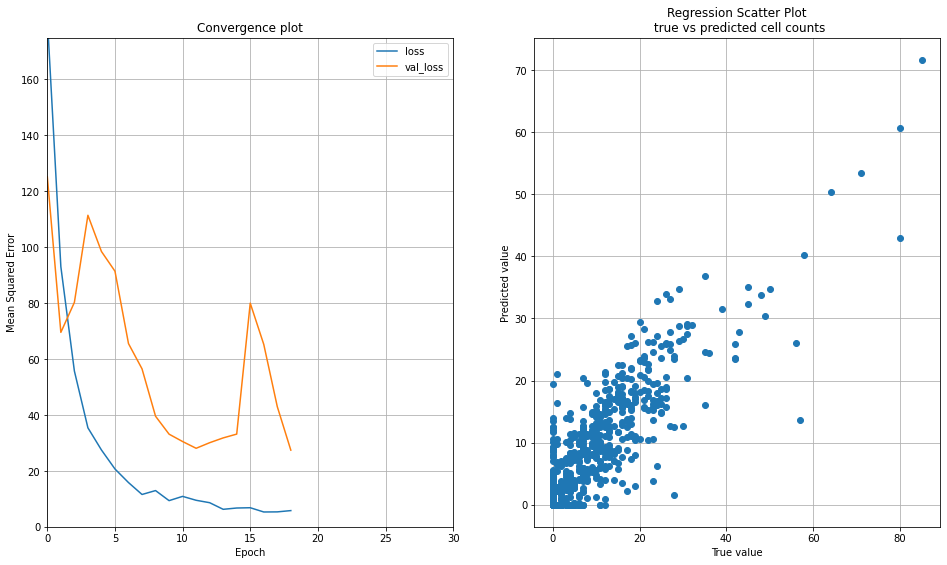

In [5]:
#%%Evaluation
fig= plt.figure(figsize=(16,9))


#Convergence plot
ax = fig.add_subplot(1,2,1)
ax.plot(history.history['loss'], label='loss'); ax.plot(history.history['val_loss'], label='val_loss')
ax.set_title('Convergence plot'); ax.set_xlim([0, 30]); ax.set_ylim([0, 175]); ax.set_xlabel('Epoch')
ax.set_ylabel('Mean Squared Error'); ax.legend(); ax.grid(True)

#Scatter plot
ax = fig.add_subplot(1,2,2)
pred = model.predict(x= test_batches, verbose=0)
pred[pred<0] = 0 #prevend values lower than zero and set those to zero
ax.plot(Y2[:,0], pred,'o');ax.grid();ax.set_xlabel('True value');ax.set_ylabel('Predicted value');
ax.set_title('Regression Scatter Plot\n true vs predicted cell counts')

#Metrics
pred = np.reshape(pred,(len(pred),))
print('| Model: CNN\t| RMSE\t\t| Pearsons Corr. Coeff.\t| Spearmans Corr. Coeff.| R2 score\t|')
print('--------------------------------------------------------------------------------------------------')
print('| \t\t| %1.3f\t\t| %1.4f\t\t| %1.3f\t\t\t| %1.3f\t\t|' % (np.sqrt(metrics.mean_squared_error(Y2[:,0], pred)),
                                                            stats.pearsonr(Y2[:,0], pred)[0],
                                                            stats.spearmanr(Y2[:,0], pred)[0],
                                                            metrics.r2_score(Y2[:,0], pred)))
 fig.tight_layout()

### b.

FOLD No.0
| Model: CNN	| RMSE		| Pearsons Corr. Coeff.	| Spearmans Corr. Coeff.| R2 score	|
-------------------------------------------------------------------------------------------------
| 		| 6.706		| 0.850	| 0.805			| 0.645		|
FOLD No.1
| Model: CNN	| RMSE		| Pearsons Corr. Coeff.	| Spearmans Corr. Coeff.| R2 score	|
-------------------------------------------------------------------------------------------------
| 		| 5.516		| 0.894	| 0.845			| 0.789		|
FOLD No.2
| Model: CNN	| RMSE		| Pearsons Corr. Coeff.	| Spearmans Corr. Coeff.| R2 score	|
-------------------------------------------------------------------------------------------------
| 		| 6.073		| 0.895	| 0.833			| 0.750		|


<function matplotlib.pyplot.show(close=None, block=None)>

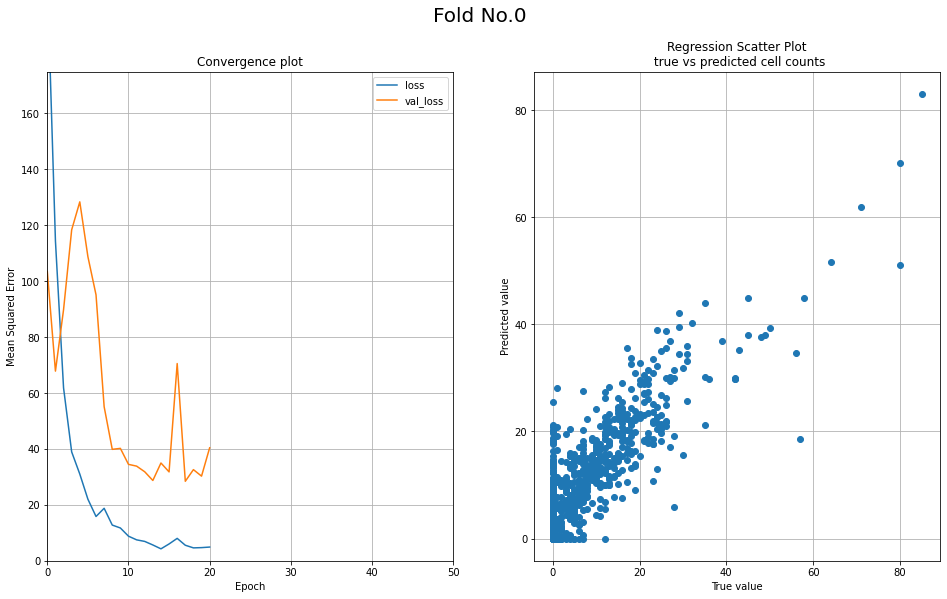

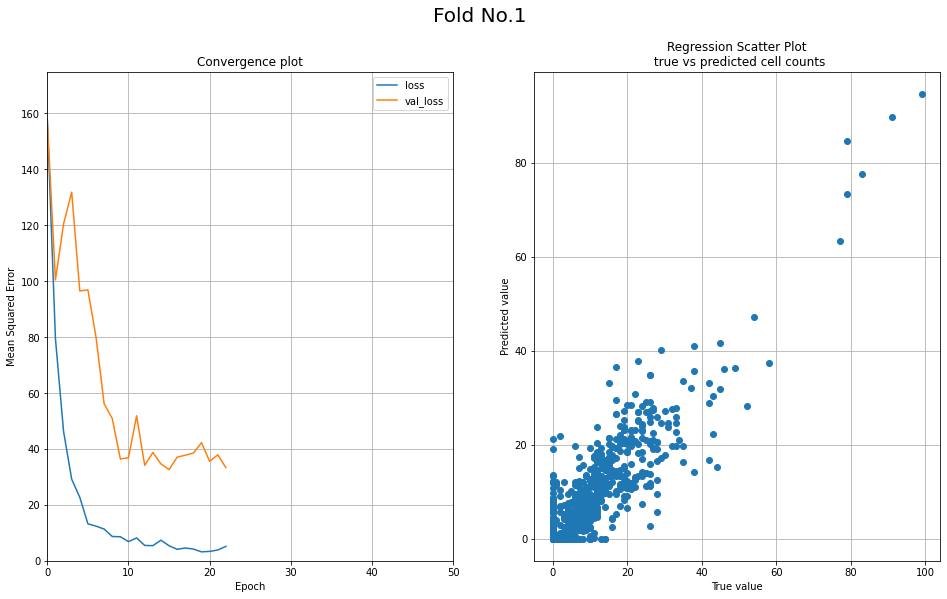

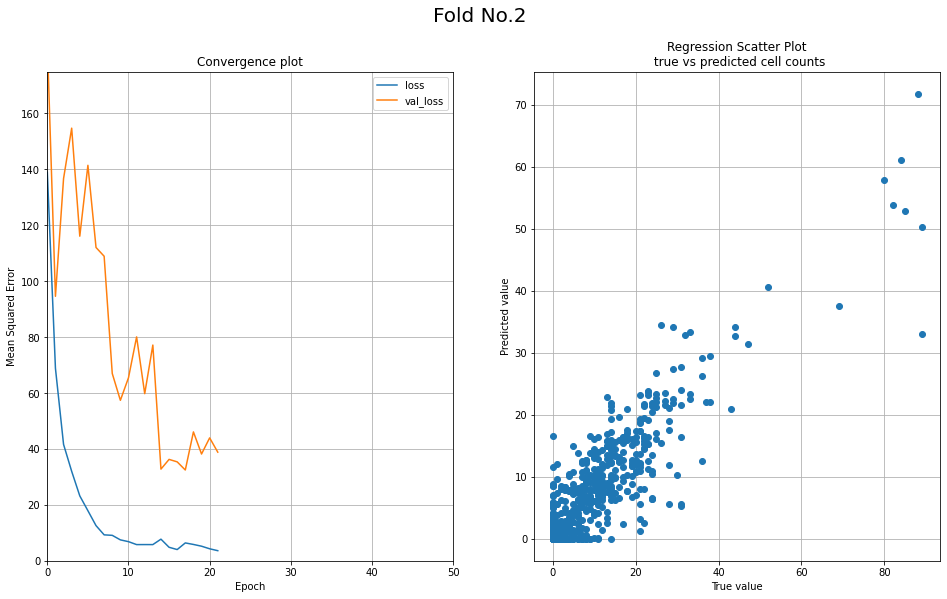

In [3]:
%matplotlib inline  
for i in range (0,3):
    print('FOLD No.%i' %i)
    batch_size = 32
    fld = np.array([[0, 1, 2], [1, 2, 0], [2, 0, 1]])
    #permutation matrix or indexing matrix
    # Following the model in the forum:
    # "In 3-fold CV:
    # step-1 use F1+F2 for training and validation, F3 for test and calculate performance metrics on F3
    # step-2 use F1+F3 for training and validation, F2 for test and calculate performance metrics on F2
    # step-3 use F2+F3 for training and validation, F1 for test and calculate performance metrics on F1"
    
    train_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input).flow(
         images[folds == fld[0,i]], counts[folds == fld[0,i]][:,0], batch_size = batch_size)
    valid_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input).flow(
         images[folds == fld[1,i]], counts[folds == fld[1,i]][:,0], batch_size = batch_size)
    test_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input).flow(
         images[folds == fld[2,i]], counts[folds == fld[2,i]][:,0], batch_size = batch_size, shuffle=False)

    #Same pretrained model as in a.
    mobile = tf.keras.applications.mobilenet.MobileNet()
    #mobile.summary()
    x = mobile.layers[-6].output
    output = Dense(units=1, activation='relu')(x)
    model = keras.Model(inputs=mobile.input, outputs=output)

    for layer in model.layers[:-23]:
        layer.trainable = False

    #model.summary()
    epochs = 50
    callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, min_delta = 1, mode='min')# baseline = 130)
    model.compile(optimizer=Adam(lr=0.0001), loss='mse', metrics=['accuracy'])
    history = model.fit(x=train_batches,
                steps_per_epoch=len(train_batches),
                validation_data=valid_batches,
                validation_steps=len(valid_batches),
                epochs=epochs, callbacks = [callback], verbose=0)
    
    #Evaluation
    fig= plt.figure(figsize=(16,9))
    fig.suptitle('Fold No.%s' %i , fontsize=20)
    
    #Convergence plot
    ax = fig.add_subplot(1,2,1)
    ax.plot(history.history['loss'], label='loss'); ax.plot(history.history['val_loss'], label='val_loss')
    ax.set_title('Convergence plot'); ax.set_xlim([0, epochs]); ax.set_ylim([0, 175]); ax.set_xlabel('Epoch')
    ax.set_ylabel('Mean Squared Error'); ax.legend(); ax.grid(True)

    #Scatter plot
    ax = fig.add_subplot(1,2,2)
    pred = model.predict(x= test_batches, verbose=0)

    pred = np.reshape(pred,(len(pred),))
    pred[pred<0] = 0 #prevend values lower than zero and set those to zero
    ax.plot(counts[folds == fld[2,i]][:,0], pred,'o');ax.grid();ax.set_xlabel('True value');ax.set_ylabel('Predicted value');
    ax.set_title('Regression Scatter Plot\n true vs predicted cell counts')

    #Metrics
    print('| Model: CNN\t| RMSE\t\t| Pearsons Corr. Coeff.\t| Spearmans Corr. Coeff.| R2 score\t|')
    print('-------------------------------------------------------------------------------------------------')
    print('| \t\t| %1.3f\t\t| %1.3f\t| %1.3f\t\t\t| %1.3f\t\t|' % (np.sqrt(metrics.mean_squared_error(counts[folds == fld[2,i]][:,0], pred)),
                                                                stats.pearsonr(counts[folds == fld[2,i]][:,0], pred)[0],
                                                                stats.spearmanr(counts[folds == fld[2,i]][:,0], pred)[0],
                                                                metrics.r2_score(counts[folds == fld[2,i]][:,0], pred)))
    fig.tight_layout()
    plt.show 

### c.

FOLD No.1
| Model: MobileNet	| RMSE		| Pearsons C. C.	| Spearmans C. C.	| R2 score	|
---------------------------------------------------------------------------------------------------------
| Cell type: T1		| 06.133	| 00.863		| 00.798		| 00.703	|
---------------------------------------------------------------------------------------------------------
| Cell type: T2		| 02.780	| 00.859		| 00.561		| 00.715	|
---------------------------------------------------------------------------------------------------------
| Cell type: T3		| 03.190	| 00.681		| 00.703		| 00.454	|
---------------------------------------------------------------------------------------------------------
| Cell type: T4		| 00.065	| -0.003		| -0.005		| -2.321	|
---------------------------------------------------------------------------------------------------------
| Cell type: T5		| 05.741	| 00.904		| 00.769		| 00.790	|
----------------------------------------------------------------------------------------------------

C:\Users\Felipe\Anaconda3\lib\site-packages\scipy\stats\stats.py:3913: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())
C:\Users\Felipe\Anaconda3\lib\site-packages\scipy\stats\stats.py:4264: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


| Cell type: T5		| 04.648	| 00.923		| 00.782		| 00.847	|
---------------------------------------------------------------------------------------------------------
| Cell type: T6		| 00.589	| 00.122		| 00.120		| -25.409	|
FOLD No.3
| Model: MobileNet	| RMSE		| Pearsons C. C.	| Spearmans C. C.	| R2 score	|
---------------------------------------------------------------------------------------------------------
| Cell type: T1		| 05.253	| 00.902		| 00.842		| 00.813	|
---------------------------------------------------------------------------------------------------------
| Cell type: T2		| 03.312	| 00.870		| 00.567		| 00.690	|
---------------------------------------------------------------------------------------------------------
| Cell type: T3		| 03.253	| 00.665		| 00.691		| 00.434	|
---------------------------------------------------------------------------------------------------------
| Cell type: T4		| 00.219	| 000nan		| 000nan		| -0.001	|
------------------------------------------

C:\Users\Felipe\Anaconda3\lib\site-packages\scipy\stats\stats.py:3913: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())
C:\Users\Felipe\Anaconda3\lib\site-packages\scipy\stats\stats.py:4264: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


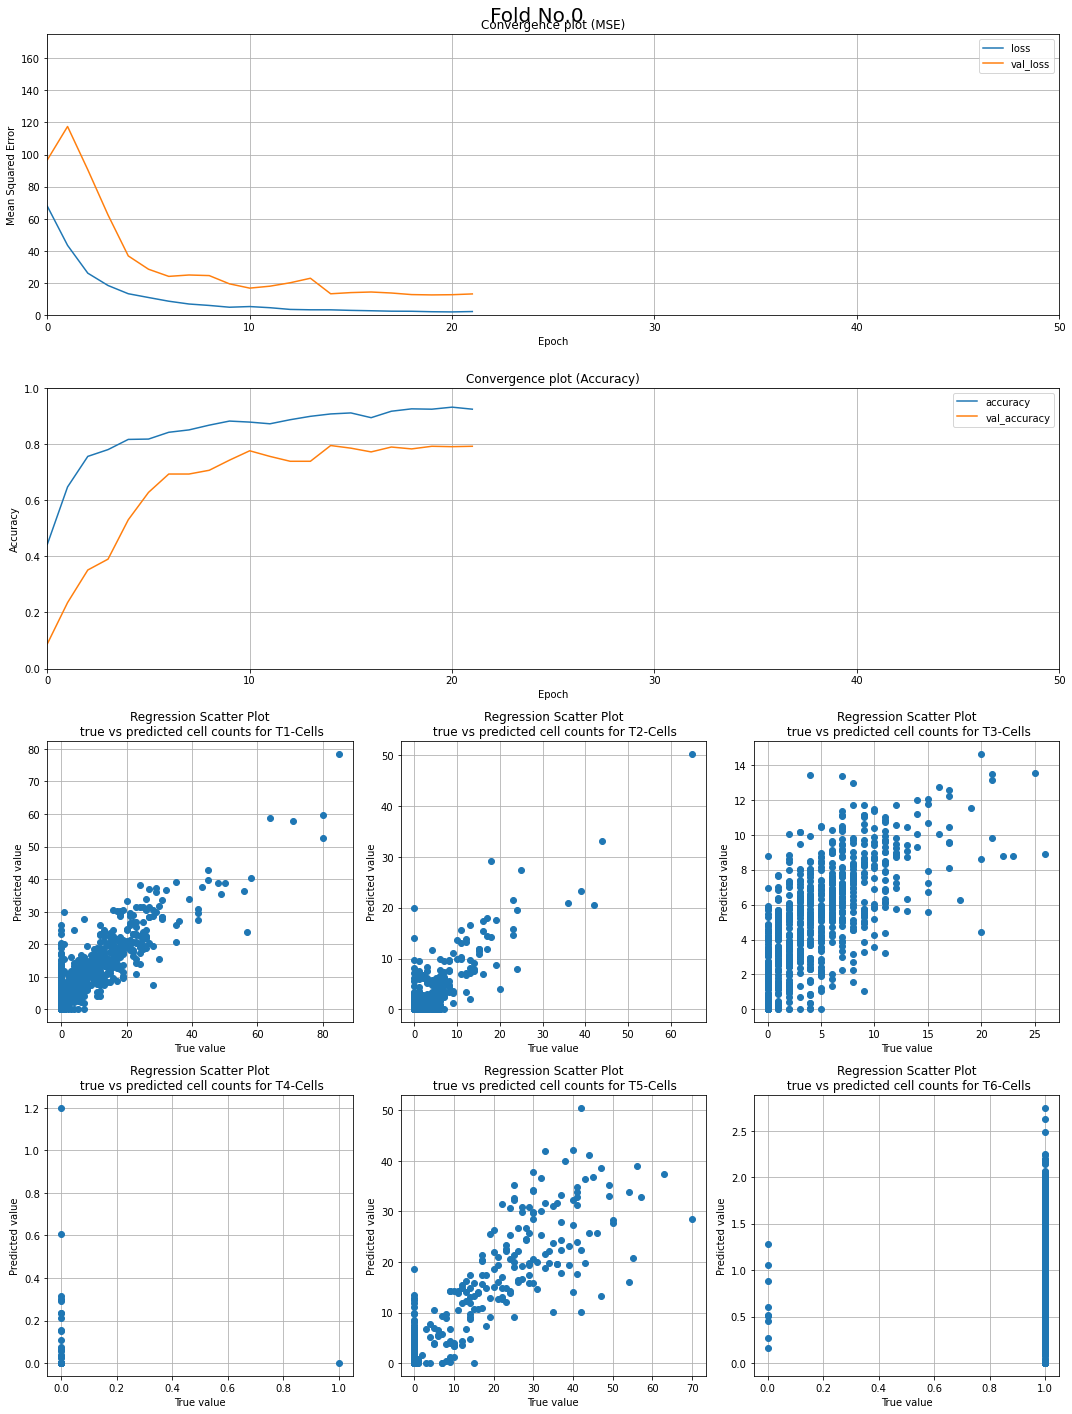

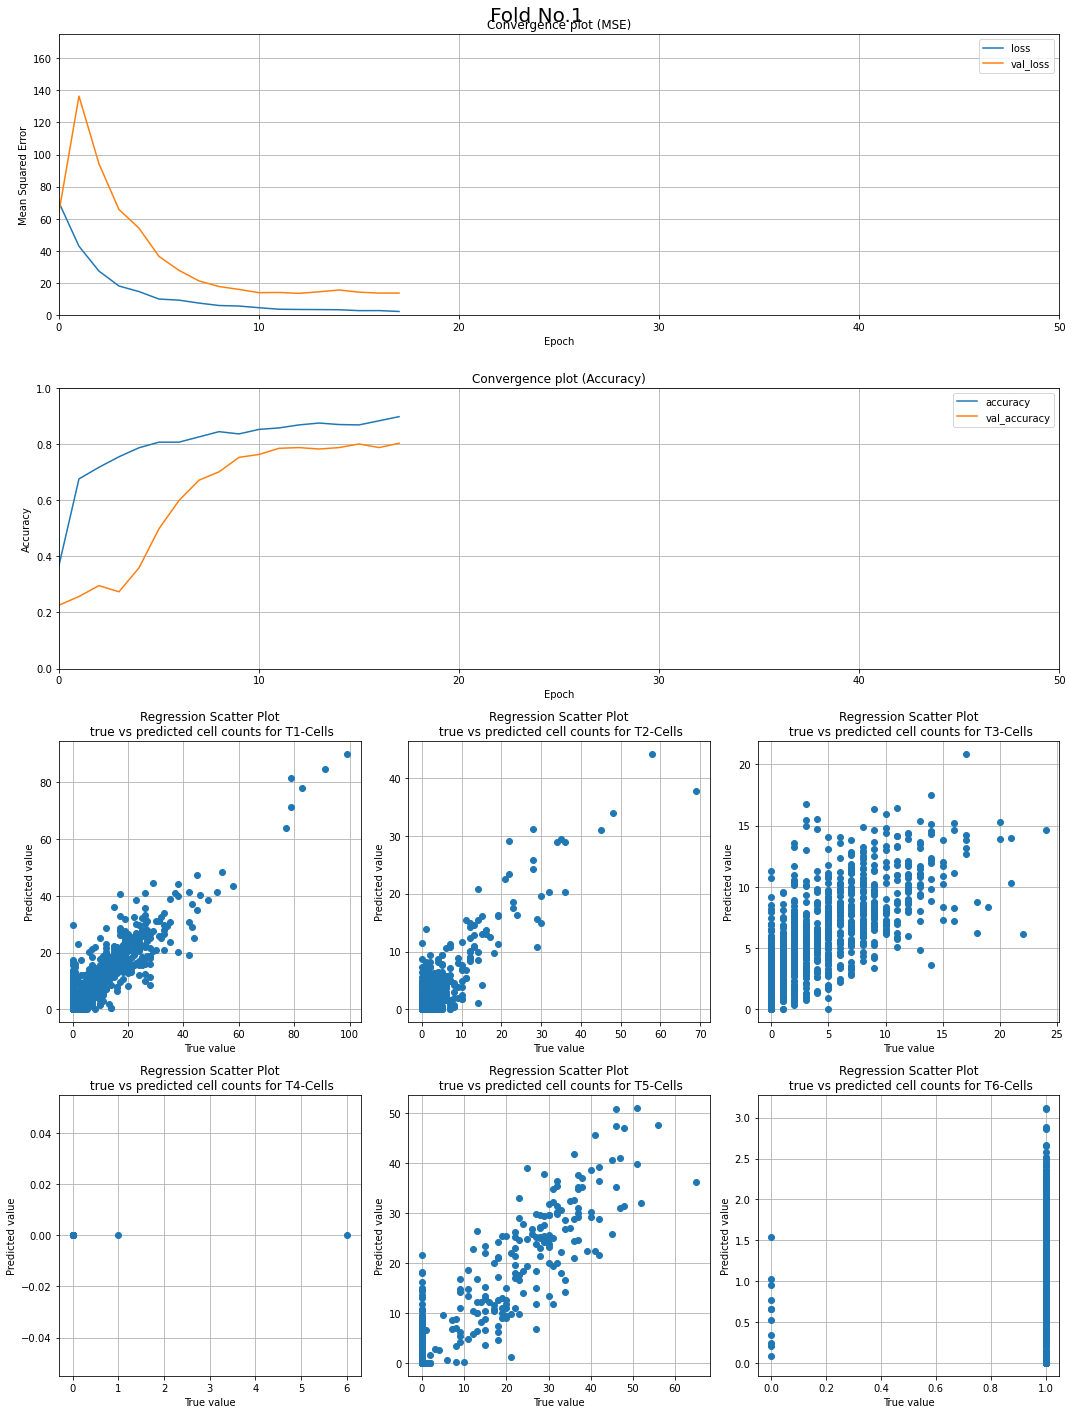

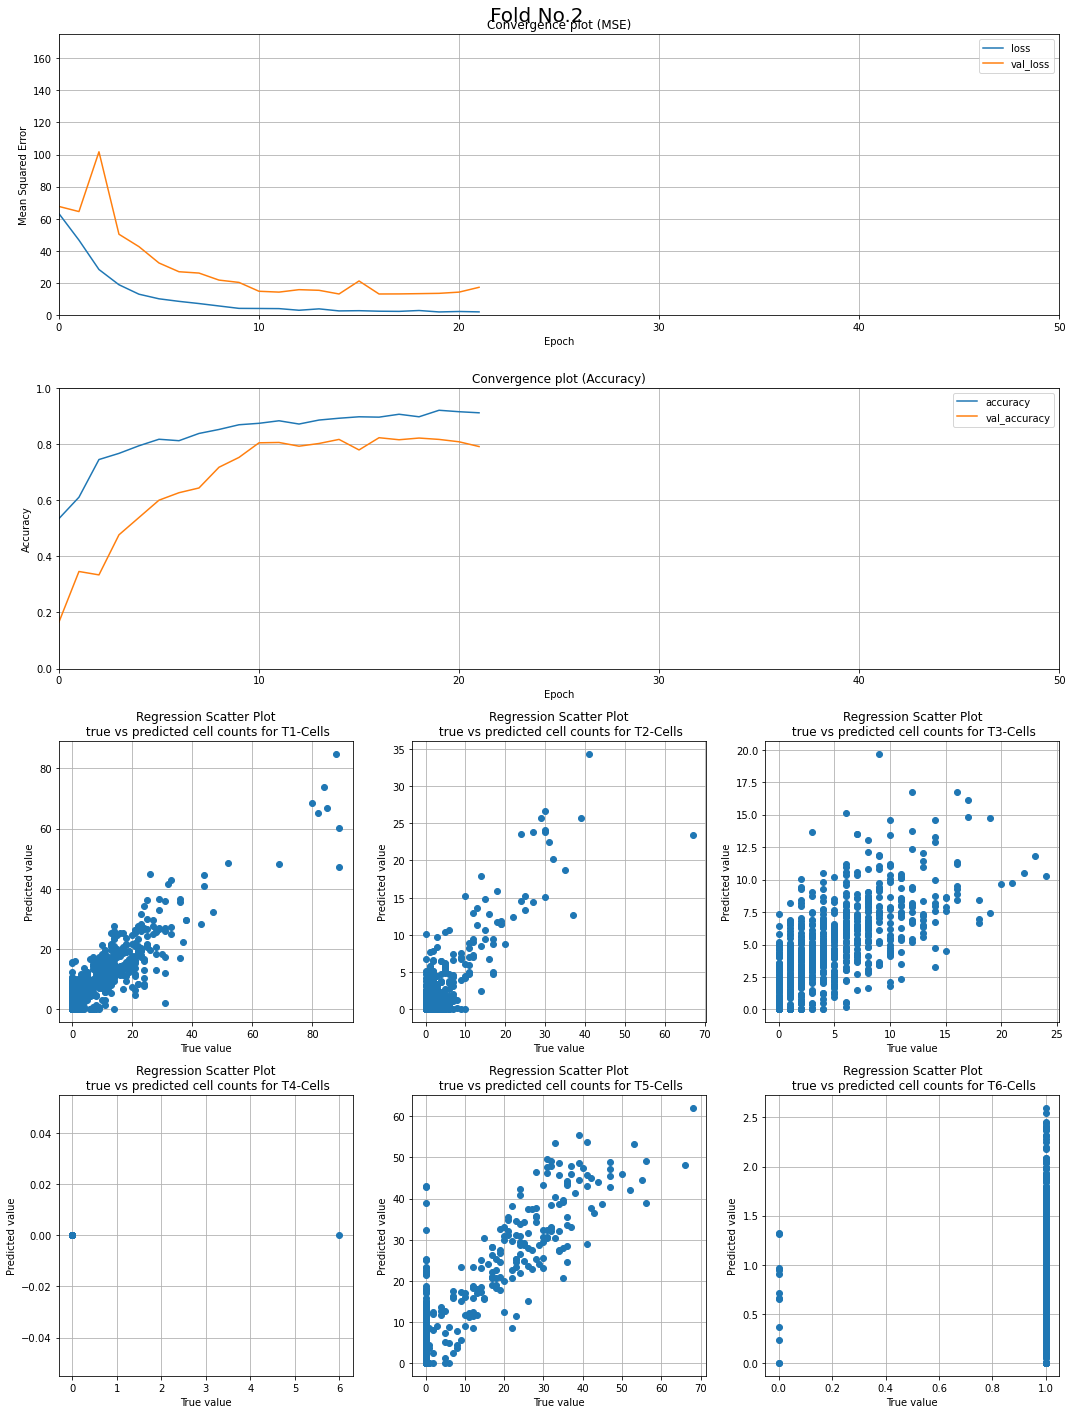

In [31]:
for i in range (0,3): #for-loop over folds
    print('FOLD No.%i' %(i+1))
    #preprocessing and split data as in b. 
    batch_size = 32
    fld = np.array([[0, 1, 2], [1, 2, 0], [2, 0, 1]])
    train_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input).flow(
         images[folds == fld[0,i]], counts[folds == fld[0,i]], batch_size = batch_size)
    valid_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input).flow(
         images[folds == fld[1,i]], counts[folds == fld[1,i]], batch_size = batch_size)
    test_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input).flow(
         images[folds == fld[2,i]], counts[folds == fld[2,i]], batch_size = batch_size, shuffle=False)
    
    # Represenation: same model as in b, but which delivers now a matrix of values in which each column represents the
    # cell-count of each cell typ. So the model does not fit over only T1-Cells but over all cell types.
    mobile = tf.keras.applications.mobilenet.MobileNet() 
    x = mobile.layers[-6].output
    output = Dense(units=6, activation='relu')(x)
    model = Model(inputs=mobile.input, outputs=output)

    for layer in model.layers[:-23]:
        layer.trainable = False

    epochs = 50
    callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, min_delta = 1, mode='min')# baseline = 130)
    model.compile(optimizer=Adam(lr=0.0001), loss='mse', metrics=['accuracy'])
    history = model.fit(x=train_batches,
                steps_per_epoch=len(train_batches),
                validation_data=valid_batches,
                validation_steps=len(valid_batches),
                epochs=epochs, callbacks = [callback], verbose=0)
    
    #Evaluation
    fig= plt.figure(figsize=(15, 20))
    fig.suptitle('Fold No.%i' %i , fontsize=20)
    
    #Convergence plot for MSE
    ax = fig.add_subplot(4,1,1)
    ax.plot(history.history['loss'], label='loss'); ax.plot(history.history['val_loss'], label='val_loss')
    ax.set_title('Convergence plot (MSE)'); ax.set_xlim([0, epochs]); ax.set_ylim([0, 175]); ax.set_xlabel('Epoch')
    ax.set_ylabel('Mean Squared Error'); ax.legend(); ax.grid(True)
    
    #Convergence plot for accuracy
    ax = fig.add_subplot(4,1,2)
    ax.plot(history.history['accuracy'], label='accuracy'); ax.plot(history.history['val_accuracy'], label='val_accuracy')
    ax.set_title('Convergence plot (Accuracy)'); ax.set_xlim([0, epochs]); ax.set_ylim([0, 1]); ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy'); ax.legend(); ax.grid(True)

    #predict
    pred = model.predict(x= test_batches, verbose=0)
    pred[pred<0] = 0 #prevend values lower than zero and set those to zero
    
    #Scatter plot
    print('| Model: MobileNet\t| RMSE\t\t| Pearsons C. C.\t| Spearmans C. C.\t| R2 score\t|')
    for j in range (0,6):
        ax = fig.add_subplot(4,3,7+j)
        ax.plot(counts[folds == fld[2,i]][:,j], pred[:,j],'o');ax.grid();ax.set_xlabel('True value');ax.set_ylabel('Predicted value');
        ax.set_title('Regression Scatter Plot\n true vs predicted cell counts for T%i-Cells' %(j+1))
    
        #Metrics
        print('---------------------------------------------------------------------------------------------------------')
        print('| Cell type: T%i\t\t| %06.3f\t| %06.3f\t\t| %06.3f\t\t| %06.3f\t|' % (j+1, np.sqrt(metrics.mean_squared_error(counts[folds == fld[2,i]][:,j], pred[:,j])),
                                                                    stats.pearsonr(counts[folds == fld[2,i]][:,j], pred[:,j])[0],
                                                                    stats.spearmanr(counts[folds == fld[2,i]][:,j], pred[:,j])[0],
                                                                    metrics.r2_score(counts[folds == fld[2,i]][:,j], pred[:,j])))
    fig.tight_layout()
    plt.show

## Consolidation table

| Model | RMSE | Pearsons Correlation Coefficent | Spearmans Correlation Coefficent | R2-Score |
| --- | --- | --- |--- |--- |
|2 ii. a.|
| OLS (Average)| 9.9400	| 0.5809 | 0.5754 | 0.3116 |
| OLS (Variance)|11.8771	| 0.2216 | 0.1135 | 0.0406 |
| OLS (Entropy)|10.8335	| 0.4572 | 0.4222 | 0.1855 |
| b. via Sklearn|
| MLP (Average)| 10.6813	| 0.5075		| 0.4876		| 0.2253	|
| MLP (Variance)| 11.9266	| 0.1932		| 0.1246		| 0.0341	|
| MLP (Entropy)| 11.0983	| 0.4120		| 0.3887		| 0.1636	|
| b. via Keras |
| MLP (Average)| 10.4240	| 0.5268		| 0.4920		| 0.2591	|
| MLP (Variance)| 12.6762	| 0.2383		| 0.3046		| -0.1311	|
| MLP (Entropy)| 11.0934	| 0.4205		| 0.3960		| 0.1601	|
| c.|
| SVR (Average)| 10.1522	| 0.5729		| 0.6081		| 0.2998	|
| SVR (Variance)| 11.8468	| 0.2923		| 0.4417		| 0.0356	|
| SVR (Entropy)| 10.5401	| 0.5233		| 0.5252		| 0.2443	|
|3)a. |
| CNN with my preprocessor|8.931		| 0.6118		| 0.537			| 0.370	|
| |
| CNN with MobileNet|5.592		| 0.8707		| 0.827			| 0.753		|
|b. |
| CNN with MobileNet Fold No. 1| 6.706		| 0.850	| 0.805			| 0.645		|
| CNN with MobileNet Fold No. 2| 5.516		| 0.894	| 0.845			| 0.789		|
| CNN with MobileNet Fold No. 3| 6.073		| 0.895	| 0.833			| 0.750		|
| Average over Folds | 6.098 | 0.880 | 0.828 | 0.728
|c.|
| Cell type: T1	Fold No. 1	| 06.133	| 00.863		| 00.798		| 00.703	|
| Cell type: T1	Fold No. 2	| 05.314	| 00.902		| 00.841		| 00.805	|
| Cell type: T1	Fold No. 3	| 05.253	| 00.902		| 00.842		| 00.813	|
| Average over Folds | 5.567	|0.889		|0.827		|0.774
||
| Cell type: T2	Fold No. 1	| 02.780	| 00.859		| 00.561		| 00.715	|
| Cell type: T2	Fold No. 2	| 02.942	| 00.890		| 00.604		| 00.778	|
| Cell type: T2	Fold No. 3	| 03.312	| 00.870		| 00.567		| 00.690	|
| Average over Folds | 3.011 |	0.873	|	0.577 |		0.728 |
| |
| Cell type: T3	Fold No. 1	| 03.190	| 00.681		| 00.703		| 00.454	|
| Cell type: T3	Fold No. 2	| 03.706	| 00.666		| 00.690		| 00.295	|
| Cell type: T3	Fold No. 3	| 03.253	| 00.665		| 00.691		| 00.434	|
| Average over Folds | 3.383 | 0.669	|0.6957 | 0.394
| |
| Cell type: T4	Fold No. 1	| 00.065	| -0.003		| -0.005		| -2.321	|
| Cell type: T4	Fold No. 2	| 00.212	| --		| --		| -0.002	|
| Cell type: T4	Fold No. 3	| 00.219	| --		| --		| -0.001	|
| Average over Folds | 0.165 |-0.003	|	-0.005	|	-0.775
| |
| Cell type: T5	Fold No. 1	| 05.741	| 00.904		| 00.769		| 00.790	|
| Cell type: T5	Fold No. 2	| 04.648	| 00.923		| 00.782		| 00.847	|
| Cell type: T5	Fold No. 3	| 07.078	| 00.889		| 00.710		| 00.678	|
| Average over Folds |5.822 |	0.905 |	0.754 |	0.772
| |
| Cell type: T6	Fold No. 1	| 00.491	| 00.086		| 00.090		| -20.030	|
| Cell type: T6	Fold No. 2	| 00.589	| 00.122		| 00.120		| -25.409|	
| Cell type: T6	Fold No. 3	| 00.507	| 00.081		| 00.076		| -15.274	|
| Average over Folds | 0.529 |	0.096 |		0.095 |		-17.652 |

Please note that R2-Score out of the interval [-1,1] do not make any sense and should not get considered for interpretations!
Also, notice that the Correlation Coefficients for T4 could not be calculated because the predicted cell counts in Fold 2 and 3 are constantly equal to zero!